In [1]:
import numpy as np
#import gplately.pygplates as pygplates
#import ptt
import gplately
import gplately.tools as tools
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader as shpreader
import netCDF4
import warnings
from scipy import ndimage
import glob, os
from rasterio.features import rasterize
from rasterio.transform import from_bounds
import matplotlib.gridspec as gridspec
#from slabdip import SlabDipper
import matplotlib
import pandas as pd
#from cmcrameri import cm
#import gplately.pygplates as pygplates
import glob, os
import matplotlib.pyplot as plt
from plate_model_manager import PlateModelManager

from gplately import pygplates

import geopandas as gpd

# matplotlib.rcParams['font.family'] = 'Arial'
# matplotlib.rcParams['pdf.fonttype'] = 42
# matplotlib.rcParams.update({
#     "pdf.use14corefonts": True
# })

reconstruction_times = np.arange(0,1800,1)
extent_global = [-180,180,-90,90]

In [30]:
import pygplates
import glob
import os

use_local_files = True

if use_local_files:
    # Method 1: manually point to files
    #input_directory = 'shirmard25'
    #input_directory = r'./shirmard25'  # Raw string to avoid issues with backslashes
    input_directory = r'C:\Users\Hojat\OneDrive - The University of Sydney (Students)\PhD_1_Notebooks\Deposits_Rev2\shirmard25'

    # Load both rotation files
    rotation_filenames = glob.glob(os.path.join(input_directory, '*.rot')) # Include both rot files
    rotation_model = pygplates.RotationModel(rotation_filenames)

    # Load static polygons
    static_polygons = pygplates.FeatureCollection(os.path.join(input_directory, 'static_polygons.gpmlz'))
    COBs = os.path.join(input_directory, 'COBfile_1800_0.gpml')  # Use updated COB file

    # Load topology files and combine them into a single FeatureCollection
    topology_filenames = [
        os.path.join(input_directory, '250-0_plate_boundaries.gpml'),
        os.path.join(input_directory, '410-250_plate_boundaries.gpml'),
        os.path.join(input_directory, '1800-1000_plate_boundaries.gpml'),
        os.path.join(input_directory, '1000-410_plate-boundaries.gpml'),  # Corrected file name
        os.path.join(input_directory, '1000-410-Convergence.gpml'),
        os.path.join(input_directory, '1000-410-Divergence.gpml'),
        os.path.join(input_directory, '1000-410-Transforms.gpml'),
        os.path.join(input_directory, 'TopologyBuildingBlocks.gpml'),
    ]

    # Create an empty list to hold all the features
    all_topology_features = []

    # Load each file and append its features to the list
    for topology_filename in topology_filenames:
        fc = pygplates.FeatureCollection(topology_filename)
        all_topology_features.extend(fc)

    # Create a single FeatureCollection from the combined features
    topology_features = pygplates.FeatureCollection(all_topology_features)

    # Optionally load other geological features if needed
    continents = pygplates.FeatureCollection(os.path.join(input_directory, 'shapes_continents.gpmlz'))
    COBs = pygplates.FeatureCollection(os.path.join(input_directory, 'COBfile_1800_0.gpml'))
    shapes_coasts = pygplates.FeatureCollection(os.path.join(input_directory, 'shapes_coasts.gpmlz'))

    # Create PlateReconstruction model
    model = gplately.PlateReconstruction(rotation_model=rotation_model, 
                                         topology_features=topology_features, 
                                         static_polygons=static_polygons)

    # Now you can proceed with your reconstruction and plotting...


In [31]:
gplot = gplately.PlotTopologies(model,
                                    coastlines = shapes_coasts,
                                    continents =continents,
                                    COBs =COBs,
                                    time=1800
                                    #anchor_plate_id=0,
                                   )

In [32]:
reconstruction_time_map = 50

In [33]:
### Load craton database
Craton_HS_filename = "data/Craton_HS_2B_PLATEID1/Craton_HS_2B_Smoothed.shp"
Craton_HS_features = pygplates.FeatureCollection(Craton_HS_filename)
reconstructed_Craton_HS_features = model.reconstruct(Craton_HS_features, reconstruction_time_map)
#deposits = '/data/Craton_HS_2B_PLATEID1/Craton_Deposits_PLATEID1.gpml'

# Test

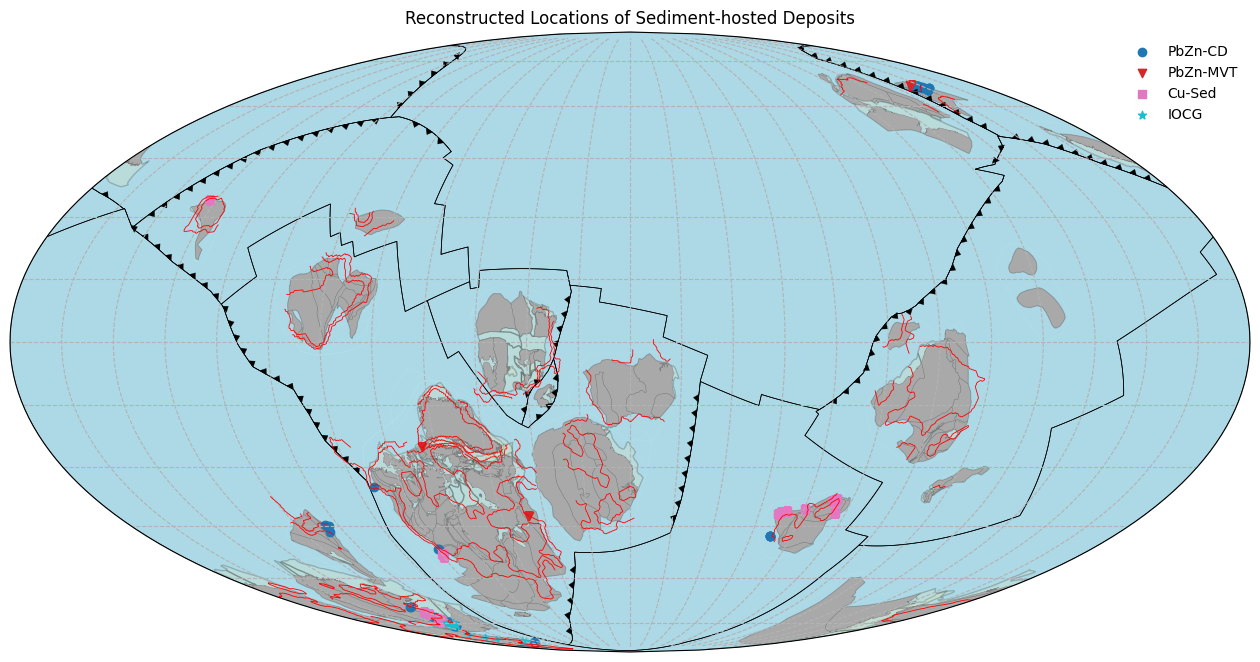

In [34]:
# Path to your shapefile
shapefile_path = 'data/Craton_HS_2B_PLATEID1/Craton_Deposits_PLATEID1.shp'

# Read the shapefile into a GeoDataFrame
gdf = gpd.read_file(shapefile_path)

# Dictionary to hold DataFrames for each type
metal_dict = dict()

# List of commodities (not used in the filtering, just for reference)
commodities = ['Cu (Mt)', 'Pb (Mt)', 'Zn (Mt)', 'Ni (Mt)']

# Get unique types from the 'Type' column
types = gdf['Type'].unique()

# Filter data by type
for type_name in types:
    df = gdf[gdf['Type'] == type_name]
    
    # Ensure that the 'Age' column is present and filter data
    if 'Age' in df.columns:
        df = df[df['Age'].notna()]
        df = df[df['Age'] > 0]  # Remove rows where Age = 0
        df = df[df['Age'] <= 1800]
        
        if df.shape[0] > 0:
            metal_dict[type_name] = df

# Initialize pygplates model (assuming you have the model defined)
# model = pygplates.PlateModel('path_to_your_plate_model')  # Update this with the path to your plate model

# Process each type
symbols = ['o', 'v', 's', '*', 'd', '^', 'P'] * 2
colors = plt.cm.tab10(np.linspace(0, 1, len(metal_dict)))

# Set the reconstruction time
reconstruction_time_map = 1070

# Set up a GeoAxis plot
fig = plt.figure(figsize=(16, 12), dpi=100)
ax = fig.add_subplot(111, projection=ccrs.Mollweide(central_longitude=0))
ax.set_global()
ax.set_facecolor('lightblue')  # Change 'lightblue' to any color you prefer
ax.gridlines(color='0.7', linestyle='--', xlocs=np.arange(-180, 180, 15), ylocs=np.arange(-90, 90, 15))
ax.set_title("Reconstructed Locations of Sediment-hosted Deposits")

# Plot shapefile features and reconstructed craton features
gplot.time = reconstruction_time_map  # Ma
gplot.plot_all_topologies(ax, color='black', linewidth=0.5, tessellate_degrees=0.1)
gplot.plot_continent_ocean_boundaries(ax, color='paleturquoise', alpha=0.2, tessellate_degrees=0.1)
gplot.plot_continents(ax, facecolor='palegoldenrod', alpha=0.2)
gplot.plot_coastlines(ax, facecolor='darkgray', edgecolor='grey', linewidth=0.3)
#gplot.plot_ridges_and_transforms(ax, color='gray', tessellate_degrees=0.1)
gplot.plot_trenches(ax, color='k', linewidth=0.3, tessellate_degrees=0.1)
gplot.plot_subduction_teeth(ax, color='k', linewidth=0.2)


# gplot.plot_continents(ax, facecolor='w')
# gplot.plot_coastlines(ax, facecolor='lightgrey', alpha=0.46)
# gplot.plot_trenches(ax, color='w', linewidth=4)
# gplot.plot_all_topological_sections(ax, color='silver', tessellate_degrees=1)
# gplot.plot_trenches(ax, label = "Trenches with polarity teeth")
# gplot.plot_subduction_teeth(ax, color='k', zorder=8)

# # Reconstruct Craton_HS
reconstructed_Craton_HS_features = model.reconstruct(Craton_HS_features, reconstruction_time_map)
gplot.plot_feature(ax, reconstructed_Craton_HS_features, color='red', linewidth=0.6)

# Initialize lists for legend handles and labels
handles = []
labels = []

# Iterate over each type in metal_dict
for i, (type_name, df) in enumerate(metal_dict.items()):
    # Ensure 'Lon_' and 'Lat_' columns are present
    if 'Lon_' in df.columns and 'Lat_' in df.columns and 'Age' in df.columns:
        lon = df['Lon_'].tolist()
        lat = df['Lat_'].tolist()
        age = df['Age'].tolist()

        # Create pygplates.Points from DataFrame
        gpts = gplately.Points(
            model,
            lon,
            lat,
            plate_id=df.get('PLATEID1', []).tolist()
        )

        try:
            rlons, rlats = gpts.reconstruct(reconstruction_time_map, return_array=True)
        except Exception as e:
            print(f"Error reconstructing points for {type_name}: {e}")
            continue

        # Filter by age
        mask_age = np.array(age) >= reconstruction_time_map
        if not np.any(mask_age):
            print(f"No data points to plot for {type_name} at this time")
            continue

        # Plot points with different color and symbol for each type
        color = colors[i % len(colors)]
        symbol = symbols[i % len(symbols)]
        scatter = ax.scatter(
            rlons[mask_age], 
            rlats[mask_age], 
            color=color, 
            marker=symbol, 
            transform=ccrs.PlateCarree(), 
            label=type_name
        )

        # Append scatter plot handle and label for legend
        handles.append(scatter)
        labels.append(type_name)

# Add legend with handles and labels
ax.legend(handles=handles, labels=labels, frameon=False)

plt.show()


# convert to polygon .shp

In [44]:
# # convert_nc_masks_to_shp.py
# # Convert NetCDF continent masks (value == 1) to ESRI Shapefiles (EPSG:4326)

# from pathlib import Path
# import re
# import warnings

# import numpy as np
# import xarray as xr
# import geopandas as gpd
# from shapely.geometry import shape
# from shapely.errors import GEOSException
# from shapely.ops import unary_union
# from rasterio.transform import from_origin
# from rasterio.features import shapes

# # ----------------------------
# # USER SETTINGS (edit these)
# # ----------------------------
# in_folder  = Path(r"C:\Users\Hojat\OneDrive - The University of Sydney (Students)\PhD_1_Notebooks\Deposits_Rev2\shirmard25\continent_masks")
# out_folder = Path(r"C:\Users\Hojat\OneDrive - The University of Sydney (Students)\PhD_1_Notebooks\Deposits_Rev2\shirmard25\continent_masks_shp")

# var_hint   = "mask"     # name of mask variable if known; falls back to first 2D var
# value_keep = 1          # polygonize cells equal to this value
# simplify_tolerance = None  # e.g., 0.05 degrees to simplify polygons; or None to skip

# out_folder.mkdir(parents=True, exist_ok=True)

# # ----------------------------
# # HELPERS
# # ----------------------------
# def _parse_time_from_name(path: Path):
#     """
#     Extract trailing numeric time from filename, e.g. continent_mask_1070.0.nc -> 1070.0
#     Returns float or None if not found.
#     """
#     m = re.search(r'([0-9]+(?:\.[0-9]+)?)\s*(?=\.nc$)', path.name)
#     return float(m.group(1)) if m else None

# def _pick_var(ds: xr.Dataset, hint: str):
#     if hint in ds.variables:
#         return ds[hint]
#     # fall back to the first 2D data variable
#     for v in ds.data_vars:
#         if ds[v].ndim == 2:
#             return ds[v]
#     # last resort: first data var (any ndim==2 not found)
#     if ds.data_vars:
#         return ds[list(ds.data_vars)[0]]
#     raise ValueError("No data variables found in NetCDF dataset.")

# def _wrap_longitudes(da: xr.DataArray):
#     """
#     Wrap 0–360 longitudes to -180–180 if needed, and sort by lon.
#     Returns updated DataArray and inferred lat/lon names.
#     """
#     lat_name = next(n for n in da.dims if "lat" in n.lower())
#     lon_name = next(n for n in da.dims if "lon" in n.lower())
#     lons = da[lon_name]
#     if float(lons.max()) > 180.0:
#         lon_wrapped = ((lons + 180) % 360) - 180
#         da = da.assign_coords({lon_name: lon_wrapped}).sortby(lon_name)
#     return da, lat_name, lon_name

# def _ensure_lat_descending(da: xr.DataArray, lat_name: str):
#     """
#     Rasterio's transform assumes row 0 is the top (max latitude).
#     If lat is ascending, flip the array so row index increases southward.
#     Returns (array, lats, lons, lon_name, flip_applied)
#     """
#     dims = list(da.dims)
#     lats = da[lat_name].values
#     lon_name = next(n for n in dims if n != lat_name)
#     lons = da[lon_name].values

#     arr = da.values
#     flip = False
#     if lats[0] < lats[-1]:  # ascending south->north
#         arr = np.flipud(arr)
#         lats = lats[::-1]
#         flip = True
#     return arr, lats, lons, lon_name, flip

# # ----------------------------
# # CORE CONVERTER
# # ----------------------------
# def netcdf_mask_to_shp(nc_path: Path, out_dir: Path, var_hint="mask", value_keep=1, simplify_tolerance=None):
#     """
#     Convert one NetCDF mask to a shapefile of polygons where mask == value_keep.
#     """
#     print(f"Processing: {nc_path.name}")
#     with xr.open_dataset(nc_path) as ds:
#         da = _pick_var(ds, var_hint)
#         da, lat_name, lon_name = _wrap_longitudes(da)

#         # Boolean mask: True where cell matches target
#         mask_bool = (da == value_keep)

#         # Prepare array and georeferencing
#         arr, lats, lons, lon_name, _ = _ensure_lat_descending(mask_bool, lat_name)
#         if arr.dtype != np.uint8:
#             arr = arr.astype(np.uint8)

#         if len(lons) < 2 or len(lats) < 2:
#             raise ValueError("Longitude/Latitude arrays must have at least 2 points each.")

#         xres = float(np.abs(np.mean(np.diff(lons))))
#         yres = float(np.abs(np.mean(np.diff(lats))))
#         xmin = float(lons.min()) - xres / 2.0
#         ymax = float(lats.max()) + yres / 2.0
#         transform = from_origin(xmin, ymax, xres, yres)

#         # Polygonize: shapes() yields (geojson_geom, value) for each region
#         geoms = []
#         for geom, val in shapes(arr, transform=transform):
#             if val != 1:
#                 continue
#             try:
#                 poly = shape(geom).buffer(0)
#                 if simplify_tolerance:
#                     poly = poly.simplify(simplify_tolerance, preserve_topology=True)
#                 if not poly.is_empty:
#                     geoms.append(poly)
#             except GEOSException:
#                 continue

#         if not geoms:
#             print("  -> No polygons with the requested value; skipping.")
#             return None

#         # Optional merge of overlapping polygons
#         try:
#             merged = unary_union(geoms)
#             if merged.geom_type == "Polygon":
#                 geoms = [merged]
#             elif merged.geom_type == "MultiPolygon":
#                 geoms = list(merged.geoms)
#         except GEOSException:
#             pass

#         # Attributes must match geometry count (fix for scalar columns)
#         time_ma = _parse_time_from_name(nc_path)
#         n = len(geoms)
#         gdf = gpd.GeoDataFrame(
#             {"source": [nc_path.name]*n, "time_Ma": [time_ma]*n},
#             geometry=geoms,
#             crs="EPSG:4326"
#         )

#     # Save shapefile
#     out_path = out_dir / (nc_path.stem + ".shp")
#     with warnings.catch_warnings():
#         warnings.simplefilter("ignore")
#         gdf.to_file(out_path, driver="ESRI Shapefile")
#     print(f"  -> Wrote {out_path}")
#     return out_path

# # ----------------------------
# # BATCH PROCESS
# # ----------------------------
# def main():
#     nc_files = sorted(in_folder.glob("*.nc"))
#     if not nc_files:
#         print(f"No NetCDF files found in {in_folder}")
#         return

#     for nc in nc_files:
#         try:
#             netcdf_mask_to_shp(
#                 nc, out_folder,
#                 var_hint=var_hint,
#                 value_keep=value_keep,
#                 simplify_tolerance=simplify_tolerance
#             )
#         except Exception as e:
#             print(f"[ERROR] {nc.name}: {e}")

# if __name__ == "__main__":
#     main()


In [ ]:
# Test

Using continent mask (SHP): continent_mask_900.0.shp


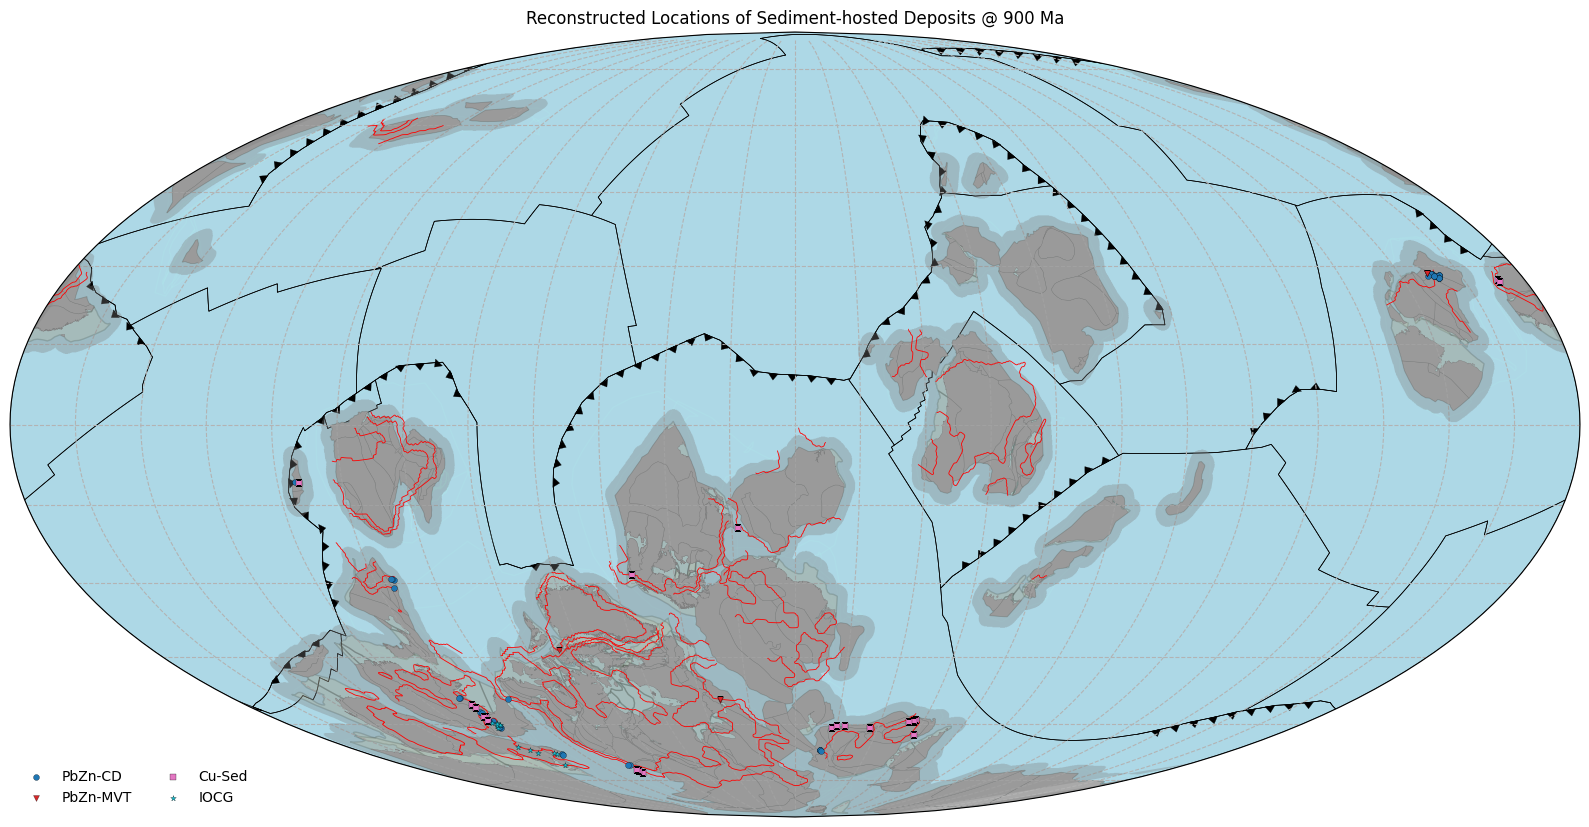

In [46]:
# --- Movie.ipynb: full plotting cell with single-time SHP mask overlay ---

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs

import pygplates
import gplately  # keep the package; don't alias plot module as "gplot"
from shapely.ops import unary_union
from shapely.errors import GEOSException

# =========================
# USER PATHS / PARAMETERS
# =========================
shapefile_path = r'data/Craton_HS_2B_PLATEID1/Craton_Deposits_PLATEID1.shp'  # >>> EDIT if needed
continent_masks_folder = Path(
    r"C:\Users\Hojat\OneDrive - The University of Sydney (Students)\PhD_1_Notebooks\Deposits_Rev2\shirmard25\continent_masks_shp"
)
reconstruction_time_map = 900  # Ma

# =========================
# HELPERS
# =========================
def add_continent_masks_shp(ax, files, alpha=0.35, zorder=2, facecolor="0.4", edgecolor="none"):
    """
    Read one or more shapefiles (EPSG:4326 preferred), optionally dissolve,
    and overlay as a semi-transparent fill on the Cartopy axis.
    """
    files = list(files)
    if not files:
        print("No shapefiles provided for continent masks.")
        return None

    all_geoms = []
    for f in files:
        try:
            gdf = gpd.read_file(f)
        except Exception as e:
            print(f"  ! Failed to read {f}: {e}")
            continue

        # Ensure WGS84 for plotting with PlateCarree
        if gdf.crs is None:
            print(f"  ! {f.name}: CRS missing; assuming EPSG:4326.")
            gdf.set_crs(epsg=4326, inplace=True)
        elif gdf.crs.to_epsg() != 4326:
            gdf = gdf.to_crs(epsg=4326)

        # Collect geometries (ignore empties)
        geoms = [g for g in gdf.geometry if g is not None and not g.is_empty]
        all_geoms.extend(geoms)

    if not all_geoms:
        print("  -> No valid geometries to plot from shapefiles.")
        return None

    # Optional dissolve to reduce draw calls
    try:
        merged = unary_union(all_geoms)
        # Normalize to iterable
        if merged.geom_type == "Polygon":
            all_geoms = [merged]
        elif merged.geom_type == "MultiPolygon":
            all_geoms = list(merged.geoms)
    except GEOSException:
        pass

    # Draw
    coll = ax.add_geometries(
        all_geoms,
        ccrs.PlateCarree(),
        facecolor=facecolor,
        edgecolor=edgecolor,
        alpha=alpha,
        zorder=zorder
    )
    return coll

def pick_mask_shp_file(folder: Path, time_ma: float, pattern="continent_mask_*.shp"):
    """
    Pick the mask shapefile whose trailing numeric time is closest to `time_ma`.
    Expects names like: continent_mask_1070.0.shp
    """
    files = list(folder.glob(pattern))
    if not files:
        return None

    candidates = []
    for f in files:
        try:
            # stem e.g. 'continent_mask_1070.0' -> last token is the time
            t = float(f.stem.split("_")[-1])
            candidates.append((abs(t - time_ma), t, f))
        except ValueError:
            continue

    if not candidates:
        return None

    candidates.sort(key=lambda x: x[0])  # by absolute difference
    return candidates[0][2]  # Path to best match

def safe_read_feature_collection(pathlike):
    if not pathlike:
        return None
    try:
        return pygplates.FeatureCollection(str(pathlike))
    except Exception as e:
        print(f"Warning: failed to load features from {pathlike}: {e}")
        return None

# =========================
# DATA PREP
# =========================
# Read deposits shapefile
gdf = gpd.read_file(shapefile_path)

# Group deposits by Type with age filtering
metal_dict = {}
types = gdf['Type'].dropna().unique()
for type_name in types:
    df = gdf[gdf['Type'] == type_name].copy()
    if 'Age' in df.columns:
        df = df[df['Age'].notna()]
        df = df[df['Age'] > 0]
        df = df[df['Age'] <= 1800]
        if df.shape[0] > 0:
            metal_dict[type_name] = df

# =========================
# MODEL / GPLOT (REUSE YOURS)
# =========================
# EXPECTED to already exist in memory:
# - rotation_model = pygplates.RotationModel([...])
# - static_polygons = pygplates.FeatureCollection(...)
# - topology_features = pygplates.FeatureCollection(...)
# - continents, COBs, shapes_coasts = FeatureCollections
# - model = gplately.PlateReconstruction(rotation_model=rotation_model,
#                                        topology_features=topology_features,
#                                        static_polygons=static_polygons)
#
# If not, build them before running this cell.

# Ensure a PlotTopologies **instance** exists and is used
try:
    gplot_obj  # may already exist from earlier cells
except NameError:
    try:
        gplot_obj = gplately.plot.PlotTopologies(
            model,
            coastlines=shapes_coasts,
            continents=continents,
            COBs=COBs,
            time=1800
        )
    except NameError as e:
        raise RuntimeError(
            "Required objects are missing. Make sure 'model', 'shapes_coasts', "
            "'continents', and 'COBs' are defined earlier in the notebook."
        ) from e

# Craton polygons (optional; load here if needed)
Craton_HS_filename = r"data/Craton_HS_2B_PLATEID1/Craton_HS_2B_Smoothed.shp"
Craton_HS_features = safe_read_feature_collection(Craton_HS_filename)

# =========================
# PLOTTING
# =========================
fig = plt.figure(figsize=(16, 12), dpi=100)
ax = fig.add_subplot(111, projection=ccrs.Mollweide(central_longitude=0))
ax.set_global()
ax.set_facecolor('lightblue')
ax.gridlines(color='0.7', linestyle='--', xlocs=np.arange(-180, 180, 15), ylocs=np.arange(-90, 90, 15))
ax.set_title(f"Reconstructed Locations of Sediment-hosted Deposits @ {reconstruction_time_map} Ma")

# tectonic layers (via PlotTopologies instance)
gplot_obj.time = reconstruction_time_map
gplot_obj.plot_all_topologies(ax, color='black', linewidth=0.5, tessellate_degrees=0.1)
gplot_obj.plot_continent_ocean_boundaries(ax, color='paleturquoise', alpha=0.2, tessellate_degrees=0.1)
gplot_obj.plot_continents(ax, facecolor='palegoldenrod', alpha=0.2)
gplot_obj.plot_coastlines(ax, facecolor='darkgray', edgecolor='grey', linewidth=0.3)
gplot_obj.plot_trenches(ax, color='k', linewidth=0.3, tessellate_degrees=0.1)
gplot_obj.plot_subduction_teeth(ax, color='k', linewidth=0.2)

# --- SHP continent mask overlay: pick closest time slice ---
mask_file = pick_mask_shp_file(continent_masks_folder, reconstruction_time_map, pattern="continent_mask_*.shp")
if mask_file:
    print(f"Using continent mask (SHP): {mask_file.name}")
    add_continent_masks_shp(ax, [mask_file], alpha=0.35, zorder=2, facecolor="0.5", edgecolor="none")
else:
    print("No continent mask shapefile matched the time; nothing overlaid.")

# --- Reconstruct & plot craton polygons (optional) ---
if Craton_HS_features:
    try:
        reconstructed_Craton_HS_features = model.reconstruct(Craton_HS_features, reconstruction_time_map)
        gplot_obj.plot_feature(ax, reconstructed_Craton_HS_features, color='red', linewidth=0.6)
    except Exception as e:
        print(f"Warning: failed to reconstruct craton features: {e}")

# --- Plot deposits by Type ---
symbols = ['o', 'v', 's', '*', 'd', '^', 'P'] * 2
colors = plt.cm.tab10(np.linspace(0, 1, max(1, len(metal_dict))))
handles, labels = [], []

for i, (type_name, df) in enumerate(metal_dict.items()):
    if not {'Lon_', 'Lat_', 'Age'}.issubset(df.columns):
        print(f"Skipping {type_name}: missing Lon_/Lat_/Age columns.")
        continue

    lon = df['Lon_'].to_list()
    lat = df['Lat_'].to_list()
    age = df['Age'].to_list()
    plate_ids = df['PLATEID1'].to_list() if 'PLATEID1' in df.columns else None

    gpts = gplately.Points(model, lon, lat, plate_id=plate_ids)

    try:
        rlons, rlats = gpts.reconstruct(reconstruction_time_map, return_array=True)
    except Exception as e:
        print(f"Error reconstructing points for {type_name}: {e}")
        continue

    # Only plot deposits at least as old as the time slice
    mask_age = np.asarray(age) >= reconstruction_time_map
    if not np.any(mask_age):
        print(f"No data points to plot for {type_name} at {reconstruction_time_map} Ma")
        continue

    color = colors[i % len(colors)]
    symbol = symbols[i % len(symbols)]
    sc = ax.scatter(
        rlons[mask_age], rlats[mask_age],
        s=18, color=color, marker=symbol,
        linewidths=0.2, edgecolors='k',
        transform=ccrs.PlateCarree(),
        label=type_name, zorder=5
    )
    handles.append(sc)
    labels.append(type_name)

if handles:
    ax.legend(handles=handles, labels=labels, frameon=False, loc='lower left', ncol=2)

plt.tight_layout()
plt.show()


# Make png files

In [8]:

# # Load craton database (Line)
# Craton_HS_filename = "data/Craton_HS_2B_PLATEID1/Craton_HS_2B_Smoothed.shp"
# Craton_HS_features = pygplates.FeatureCollection(Craton_HS_filename)

# # Load Deposits (Point)
# shapefile_path = 'data/Craton_HS_2B_PLATEID1/Craton_Deposits_PLATEID1.shp'
# gdf = gpd.read_file(shapefile_path)

# # Define size classes and corresponding symbol sizes based on TM2
# size_classes = [(0, 4), (4, 12), (12, 28), (28, 52), (52, float('inf'))]
# size_labels = ['< 4', '4-12', '12-28', '28-52', '> 52']
# size_markers = [20, 50, 80, 110, 140]  # Symbol sizes for each class

# # Function to get the marker size based on TM2 value
# def get_size(tm2_value):
#     for (low, high), size_marker in zip(size_classes, size_markers):
#         if low <= tm2_value < high:
#             return size_marker
#     return size_markers[-1]  # Return largest size if out of range

# # Dictionary to hold DataFrames for each type
# metal_dict = dict()

# # Get unique types from the 'Type' column
# types = gdf['Type'].unique()

# # Filter data by type
# for type_name in types:
#     df = gdf[gdf['Type'] == type_name]
    
#     # Ensure that the 'Age' column is present and filter data
#     if 'Age' in df.columns:
#         df = df[df['Age'].notna()]
#         df = df[df['Age'] > 0]  # Remove rows where Age = 0
#         df = df[df['Age'] <= 1800]  # Replace with your maximum reconstruction time
        
#         if df.shape[0] > 0:
#             metal_dict[type_name] = df

# # Initialize pygplates model (assuming you have the model defined)
# # model = pygplates.PlateModel('path_to_your_plate_model')  # Update this with the path to your plate model

# # Define the range of reconstruction times and interval
# reconstruction_time_range = np.arange(1800, -1, -200)

# # Define save folder for images
# save_folder = 'Movie_Images_mantle_opt_2'
# if not os.path.exists(save_folder):
#     os.makedirs(save_folder)

# # Define custom colors for each deposit type
# custom_colors = ['blue', 'red', 'orange', 'purple']  # Adjust as needed
# colors = custom_colors[:len(metal_dict)]

# # Repeat colors if there are more deposits than colors
# while len(colors) < len(metal_dict):
#     colors += custom_colors[:len(metal_dict) - len(colors)]

# def plot_and_save(reconstruction_time_map):
#     fig = plt.figure(figsize=(16, 12), dpi=200)
#     ax = fig.add_subplot(111, projection=ccrs.Mollweide(central_longitude=0))
#     ax.set_global()
#     ax.gridlines(color='0.7', linestyle='--', xlocs=np.arange(-180, 180, 15), ylocs=np.arange(-90, 90, 15))
#     ax.set_title(f"Reconstructed Locations of Craton Deposits (Time: {reconstruction_time_map} Ma)")

#     # Plot shapefile features and reconstructed craton features
#     gplot.time = reconstruction_time_map  # Ma
#     gplot.plot_all_topologies(ax, color='black', linewidth=0.5, tessellate_degrees=0.1)
#     gplot.plot_continent_ocean_boundaries(ax, color='paleturquoise', alpha=0.2, tessellate_degrees=0.1)
#     gplot.plot_continents(ax, facecolor='palegoldenrod', alpha=0.2)
#     gplot.plot_coastlines(ax, facecolor='darkgray', edgecolor='grey', linewidth=0.3)
#     #gplot.plot_ridges_and_transforms(ax, color='gray', tessellate_degrees=0.1)
#     gplot.plot_trenches(ax, color='k', linewidth=0.3, tessellate_degrees=0.1)
#     gplot.plot_subduction_teeth(ax, color='k', linewidth=0.2)
    
#     # Reconstruct Craton_HS
#     reconstructed_Craton_HS_features = model.reconstruct(Craton_HS_features, reconstruction_time_map)
#     gplot.plot_feature(ax, reconstructed_Craton_HS_features, color='saddlebrown', linewidth=0.8)

#     # Initialize lists for legend handles
#     size_legend_handles = []
#     type_legend_handles = []

#     # Plot all points with circles of varying sizes based on "TM2" values
#     for i, (type_name, df) in enumerate(metal_dict.items()):
#         lon = df['Lon_']
#         lat = df['Lat_']
#         tm2 = df['TM2']
#         ids = df['Deposit']

#         # Create pygplates.Points from DataFrame
#         gpts = gplately.Points(
#             model,
#             lon,
#             lat,
#             plate_id=df.get('PLATEID1', []).tolist()
#         )

#         try:
#             rlons, rlats = gpts.reconstruct(reconstruction_time_map, return_array=True)
#         except Exception as e:
#             print(f"Error reconstructing points for {type_name}: {e}")
#             continue

#         mask_age = df['Age'] >= reconstruction_time_map

#         for (low, high), size_marker in zip(size_classes, size_markers):
#             mask_size = (tm2 >= low) & (tm2 < high)
#             mask = mask_age & mask_size
#             scatter = ax.scatter(
#                 rlons[mask], 
#                 rlats[mask], 
#                 color=colors[i], 
#                 marker='o', 
#                 transform=ccrs.PlateCarree(), 
#                 s=size_marker,  # Set sizes based on TM2 values
#                 label=None, 
#                 edgecolor='black', 
#                 linewidth=0.5, 
#                 alpha=0.6
#             )

#             # Label points with "ID" where TM2 > 12, and avoid overlap
#             for lon, lat, tm_value, deposit_id in zip(rlons[mask], rlats[mask], tm2[mask], ids[mask]):
#                 if tm_value > 20:
#                     offset = 2  # Offset to avoid overlap
#                     ax.text(
#                         lon, 
#                         lat + offset, 
#                         deposit_id, 
#                         transform=ccrs.PlateCarree(), 
#                         fontsize=5, 
#                         ha='center', 
#                         va='bottom', 
#                         color='black', 
#                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.4)
#                     )

#     # Add legend for circle sizes
#     size_legend_handles = [plt.scatter([], [], marker='o', s=size_marker, label=label, color='gray', edgecolor='black', linewidth=0.5) for size_marker, label in zip(size_markers, size_labels)]
    
#     # Add legend for deposit types (colors)
#     type_legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=type_name, markersize=10, markerfacecolor=color, markeredgecolor='black', linewidth=0.5) for type_name, color in zip(metal_dict.keys(), colors)]
    
#     # Combine legends
#     all_handles = size_legend_handles + type_legend_handles
#     all_labels = size_labels + list(metal_dict.keys())
    
#     ax.legend(handles=all_handles, labels=all_labels, loc='upper right', title='Deposits Size (Mt), Types', frameon=False, bbox_to_anchor=(1.0, 1.16))

#     # Save the plot as an image
#     plt.savefig(os.path.join(save_folder, f'Reconstructed_Deposits_{reconstruction_time_map}.png'), bbox_inches='tight')
#     plt.close(fig)

# # Create plots and save them for each reconstruction_time_map value
# for reconstruction_time_map in reconstruction_time_range:
#     plot_and_save(reconstruction_time_map)


In [47]:

# # Load craton database (Line)
# Craton_HS_filename = "data/Craton_HS_2B_PLATEID1/Craton_HS_2B_Smoothed.shp"
# Craton_HS_features = pygplates.FeatureCollection(Craton_HS_filename)

# # Load Deposits (Point)
# shapefile_path = 'data/Craton_HS_2B_PLATEID1/Craton_Deposits_PLATEID1.shp'
# gdf = gpd.read_file(shapefile_path)
# gdf = gdf[gdf['Type'] != 'IOCG']

# # Define size classes and corresponding symbol sizes based on TM2
# size_classes = [(0, 4), (4, 12), (12, 28), (28, 52), (52, float('inf'))]
# size_labels = ['< 4', '4-12', '12-28', '28-52', '> 52']
# size_markers = [20, 50, 100, 160, 210]  # Symbol sizes for each class

# # Function to get the marker size based on TM2 value
# def get_size(tm2_value):
#     for (low, high), size_marker in zip(size_classes, size_markers):
#         if low <= tm2_value < high:
#             return size_marker
#     return size_markers[-1]  # Return largest size if out of range

# # Dictionary to hold DataFrames for each type
# metal_dict = dict()

# # Get unique types from the 'Type' column
# types = gdf['Type'].unique()

# # Filter data by type
# for type_name in types:
#     df = gdf[gdf['Type'] == type_name]
    
#     # Ensure that the 'Age' column is present and filter data
#     if 'Age' in df.columns:
#         df = df[df['Age'].notna()]
#         df = df[df['Age'] > 0]  # Remove rows where Age = 0
#         df = df[df['Age'] <= 1800]  # Replace with your maximum reconstruction time
        
#         if df.shape[0] > 0:
#             metal_dict[type_name] = df

# # Initialize pygplates model (assuming you have the model defined)
# # model = pygplates.PlateModel('path_to_your_plate_model')  # Update this with the path to your plate model

# # Define the range of reconstruction times and interval
# reconstruction_time_range = np.arange(1800, -1, -1)

# # Define save folder for images
# save_folder = 'Movie_Images'
# if not os.path.exists(save_folder):
#     os.makedirs(save_folder)

# # Define custom colors for each deposit type
# #custom_colors = ['green', 'red', 'gold', 'purple']  # Adjust as needed
# custom_colors = ['#0072B2', '#117733','#DDCC77']  # Dark Green, Light Blue, Pink, Light Yellow

# colors = custom_colors[:len(metal_dict)]

# # Repeat colors if there are more deposits than colors
# while len(colors) < len(metal_dict):
#     colors += custom_colors[:len(metal_dict) - len(colors)]

# def plot_and_save(reconstruction_time_map):
#     fig = plt.figure(figsize=(16, 12), dpi=200)
#     ax = fig.add_subplot(111, projection=ccrs.Mollweide(central_longitude=0))
#     ax.set_global()
#     ax.set_facecolor('aliceblue')  # Change 'lightblue' to any color you prefer
#     ax.gridlines(color='0.7', linestyle='--', xlocs=np.arange(-180, 180, 15), ylocs=np.arange(-90, 90, 15))
    
#     # Set a generic title without the time
#     ax.set_title("Reconstructed Locations of Craton Edge Deposits", fontsize=16)

#     # ... [rest of the existing plotting code] ...

#     # Add time information to a text box in the top left of the legend
#     time_text = plt.text(
#         0.02, 0.98,  # x, y coordinates in axes fraction
#         f"Time: {reconstruction_time_map} Ma", 
#         transform=ax.transAxes, 
#         verticalalignment='top', 
#         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
#         fontsize=15
#     )

#     # ... [rest of the existing code] ...

#     # Plot shapefile features and reconstructed craton features
#     gplot.time = reconstruction_time_map  # Ma
#     gplot.plot_all_topologies(ax, color='black', linewidth=0.5, tessellate_degrees=0.1)
#     gplot.plot_continent_ocean_boundaries(ax, color='paleturquoise', alpha=0.2, tessellate_degrees=0.1)
#     gplot.plot_continents(ax, facecolor='palegoldenrod', alpha=0.2)
#     gplot.plot_coastlines(ax, facecolor='darkgray', edgecolor='grey', linewidth=0.3)
#     #gplot.plot_ridges_and_transforms(ax, color='gray', tessellate_degrees=0.1)
#     gplot.plot_trenches(ax, color='k', linewidth=0.3, tessellate_degrees=0.1)
#     gplot.plot_subduction_teeth(ax, color='k', linewidth=0.2)
    
#     # Reconstruct Craton_HS
#     reconstructed_Craton_HS_features = model.reconstruct(Craton_HS_features, reconstruction_time_map)
#     gplot.plot_feature(ax, reconstructed_Craton_HS_features, color='saddlebrown', linewidth=0.8)

#     # Initialize lists for legend handles
#     size_legend_handles = []
#     type_legend_handles = []

#     # Plot all points with circles of varying sizes based on "TM2" values
#     for i, (type_name, df) in enumerate(metal_dict.items()):
#         lon = df['Lon_']
#         lat = df['Lat_']
#         tm2 = df['TM2']
#         ids = df['Deposit']

#         # Create pygplates.Points from DataFrame
#         gpts = gplately.Points(
#             model,
#             lon,
#             lat,
#             plate_id=df.get('PLATEID1', []).tolist()
#         )

#         try:
#             rlons, rlats = gpts.reconstruct(reconstruction_time_map, return_array=True)
#         except Exception as e:
#             print(f"Error reconstructing points for {type_name}: {e}")
#             continue

#         mask_age = df['Age'] >= reconstruction_time_map

#         for (low, high), size_marker in zip(size_classes, size_markers):
#             mask_size = (tm2 >= low) & (tm2 < high)
#             mask = mask_age & mask_size
#             scatter = ax.scatter(
#                 rlons[mask], 
#                 rlats[mask], 
#                 color=colors[i], 
#                 marker='o', 
#                 transform=ccrs.PlateCarree(), 
#                 s=size_marker,  # Set sizes based on TM2 values
#                 label=None, 
#                 edgecolor='black', 
#                 linewidth=0.5, 
#                 alpha=0.6
#             )

#             # List of deposits to label
#             deposits_to_label = [
#                 'Broken Hill', 'HYC (McArthur River)', 'Kolwezi', 'Ngwako Pan', 
#                 'Lubin', 'Gorevsk', 'Viburnum', 'Red Dog', 
#                 'Sullivan', 'Rampura', 'Changba'
#             ]
            
#             # Label points where deposit is in the list
#             for lon, lat, deposit_id in zip(rlons[mask], rlats[mask], ids[mask]):
#                 if deposit_id in deposits_to_label:
#                     offset = 2  # Offset to avoid overlap
#                     ax.text(
#                         lon, 
#                         lat + offset, 
#                         deposit_id, 
#                         transform=ccrs.PlateCarree(), 
#                         fontsize=15, 
#                         ha='center', 
#                         va='bottom', 
#                         color='black', 
#                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.4)
#                     )
        
#     # Custom labels and sizes to show in the legend
#     legend_size_labels = ['0.1', '84']
#     legend_size_markers = [20, 210]
    
#     size_legend_handles = [
#         plt.scatter([], [], marker='o', s=size, label=label, color='gray', edgecolor='black', linewidth=0.5)
#         for size, label in zip(legend_size_markers, legend_size_labels)
#     ]

        
#     # Add legend for deposit types (colors)
#     type_legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=type_name, markersize=10, markerfacecolor=color, markeredgecolor='black', linewidth=0.5) for type_name, color in zip(metal_dict.keys(), colors)]
    
#     # Add Craton Boundaries legend
#     craton_legend_handle = plt.Line2D([0], [0], color='saddlebrown', linewidth=2, label='Craton Boundaries')
    
#     # Deposit type legend at right top
#     first_legend = ax.legend(handles=type_legend_handles, 
#                              labels=list(metal_dict.keys()), 
#                              loc='upper right', 
#                              title='Deposit Types', 
#                              frameon=True, 
#                              bbox_to_anchor=(1.0, 1.01),
#                              fancybox=True, 
#                              shadow=True, fontsize=12, title_fontsize=14)
    
#     # Add the first legend to the axes
#     ax.add_artist(first_legend)
    
#     # Deposit size legend at right bottom
#     second_legend = ax.legend(handles=size_legend_handles, 
#                               #labels=size_labels, 
#                               loc='lower right', 
#                               title='Deposits Size (Mt)', 
#                               frameon=True, 
#                               bbox_to_anchor=(1.0, -0.08),
#                               fancybox=True, 
#                               shadow=True, fontsize=12, title_fontsize=14)
    
#     # Add the second legend to the axes
#     ax.add_artist(second_legend)
    
#     # Craton Boundaries legend at bottom left
#     third_legend = ax.legend(handles=[craton_legend_handle], 
#                              loc='lower left', 
#                              title='', 
#                              frameon=True, 
#                              bbox_to_anchor=(0.0, -0.08),
#                              fancybox=True, 
#                              shadow=True, fontsize=12, title_fontsize=14)

#     # Save the plot as an image
#     plt.savefig(os.path.join(save_folder, f'Reconstructed_Deposits_{reconstruction_time_map}.png'), bbox_inches='tight')
#     plt.close(fig)

# # Create plots and save them for each reconstruction_time_map value
# for reconstruction_time_map in reconstruction_time_range:
#     plot_and_save(reconstruction_time_map)


In [51]:
# --- Movie.ipynb: time-stepped plotting with single-time SHP mask overlay ---

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs

import pygplates
import gplately  # keep the package; don't alias the plot module as "gplot"
from shapely.ops import unary_union
from shapely.errors import GEOSException

# =========================
# USER PATHS / PARAMETERS
# =========================
# Craton & deposits
craton_shp = r"data/Craton_HS_2B_PLATEID1/Craton_HS_2B_Smoothed.shp"
deposits_shp = r"data/Craton_HS_2B_PLATEID1/Craton_Deposits_PLATEID1.shp"

# Folder with continent mask SHAPEFILES named like: continent_mask_0.0.shp … continent_mask_1800.0.shp
continent_masks_folder = Path(
    r"C:\Users\Hojat\OneDrive - The University of Sydney (Students)\PhD_1_Notebooks\Deposits_Rev2\shirmard25\continent_masks_shp"
)

# Time sweep and output
reconstruction_time_range = np.arange(1800, -1, -300)  # 1800 → 0 Ma (every 1 Ma)
save_folder = "Movie_Images"
os.makedirs(save_folder, exist_ok=True)

# =========================
# SIZE CLASSES (by TM2)
# =========================
size_classes = [(0, 4), (4, 12), (12, 28), (28, 52), (52, float("inf"))]
size_labels  = ['< 4', '4-12', '12-28', '28-52', '> 52']
size_markers = [20, 50, 100, 160, 210]

def get_size(tm2_value):
    for (low, high), size_marker in zip(size_classes, size_markers):
        if low <= tm2_value < high:
            return size_marker
    return size_markers[-1]

# =========================
# HELPERS
# =========================
def pick_mask_shp_file(folder: Path, time_ma: float, pattern="continent_mask_*.shp"):
    """
    Pick the mask shapefile whose trailing numeric time is closest to `time_ma`.
    Expects names like: continent_mask_1070.0.shp
    """
    files = list(folder.glob(pattern))
    if not files:
        return None

    candidates = []
    for f in files:
        try:
            t = float(f.stem.split("_")[-1])  # last token is time
            candidates.append((abs(t - time_ma), t, f))
        except ValueError:
            continue

    if not candidates:
        return None

    candidates.sort(key=lambda x: x[0])  # by absolute difference
    return candidates[0][2]

def add_continent_masks_shp(ax, files, alpha=0.35, zorder=2, facecolor="0.5", edgecolor="none"):
    """
    Read one or more shapefiles (EPSG:4326 preferred), dissolve, and overlay on the Cartopy axis.
    """
    files = list(files)
    if not files:
        print("No shapefiles provided for continent masks.")
        return None

    all_geoms = []
    for f in files:
        try:
            gdf = gpd.read_file(f)
        except Exception as e:
            print(f"  ! Failed to read {f}: {e}")
            continue

        # Ensure WGS84 for plotting with PlateCarree
        if gdf.crs is None:
            print(f"  ! {f.name}: CRS missing; assuming EPSG:4326.")
            gdf.set_crs(epsg=4326, inplace=True)
        elif gdf.crs.to_epsg() != 4326:
            gdf = gdf.to_crs(epsg=4326)

        all_geoms.extend([g for g in gdf.geometry if g is not None and not g.is_empty])

    if not all_geoms:
        print("  -> No valid geometries to plot from shapefiles.")
        return None

    try:
        merged = unary_union(all_geoms)
        if merged.geom_type == "Polygon":
            all_geoms = [merged]
        elif merged.geom_type == "MultiPolygon":
            all_geoms = list(merged.geoms)
    except GEOSException:
        pass

    return ax.add_geometries(
        all_geoms,
        ccrs.PlateCarree(),
        facecolor=facecolor,
        edgecolor=edgecolor,
        alpha=alpha,
        zorder=zorder
    )

def safe_read_feature_collection(pathlike):
    try:
        return pygplates.FeatureCollection(str(pathlike))
    except Exception as e:
        print(f"Warning: failed to load features from {pathlike}: {e}")
        return None

# =========================
# LOAD DATA
# =========================
# Craton polygons (line)
Craton_HS_features = safe_read_feature_collection(craton_shp)

# Deposits (points)
gdf = gpd.read_file(deposits_shp)
gdf = gdf[gdf['Type'] != 'IOCG']  # drop IOCG

# Group deposits by Type with age filtering
metal_dict = {}
for type_name in gdf['Type'].dropna().unique():
    df = gdf[gdf['Type'] == type_name].copy()
    if 'Age' in df.columns:
        df = df[df['Age'].notna()]
        df = df[(df['Age'] > 0) & (df['Age'] <= 1800)]
        if not df.empty:
            metal_dict[type_name] = df

# Colors for types
custom_colors = ['#0072B2', '#117733', '#DDCC77']  # extend as needed
colors = custom_colors[:len(metal_dict)]
while len(colors) < len(metal_dict):
    colors += custom_colors[:len(metal_dict) - len(colors)]

# =========================
# MODEL / GPLOT (REUSE YOURS)
# =========================
# EXPECTED to already exist in memory:
# - rotation_model, static_polygons, topology_features, continents, COBs, shapes_coasts
# - model = gplately.PlateReconstruction(...)
#
# Ensure a PlotTopologies **instance** exists (use 'gplot_obj' to avoid shadowing the module)
try:
    gplot_obj
except NameError:
    try:
        gplot_obj = gplately.plot.PlotTopologies(
            model,
            coastlines=shapes_coasts,
            continents=continents,
            COBs=COBs,
            time=1800
        )
    except NameError as e:
        raise RuntimeError(
            "Required objects are missing. Make sure 'model', 'shapes_coasts', "
            "'continents', and 'COBs' are defined earlier in the notebook."
        ) from e

# =========================
# PLOTTING
# =========================
def plot_and_save(reconstruction_time_map):
    fig = plt.figure(figsize=(16, 12), dpi=200)
    ax = fig.add_subplot(111, projection=ccrs.Mollweide(central_longitude=0))
    ax.set_global()
    ax.set_facecolor('aliceblue')
    ax.gridlines(color='0.7', linestyle='--', xlocs=np.arange(-180, 180, 15), ylocs=np.arange(-90, 90, 15))
    ax.set_title("Reconstructed Locations of Craton Edge Deposits", fontsize=16)

    # Tectonic layers
    gplot_obj.time = reconstruction_time_map
    gplot_obj.plot_all_topologies(ax, color='black', linewidth=0.5, tessellate_degrees=0.1)
    gplot_obj.plot_continent_ocean_boundaries(ax, color='paleturquoise', alpha=0.2, tessellate_degrees=0.1)
    gplot_obj.plot_continents(ax, facecolor='palegoldenrod', alpha=0.2)
    gplot_obj.plot_coastlines(ax, facecolor='darkgray', edgecolor='grey', linewidth=0.3)
    gplot_obj.plot_trenches(ax, color='k', linewidth=0.3, tessellate_degrees=0.1)
    gplot_obj.plot_subduction_teeth(ax, color='k', linewidth=0.2)

    # SHP continent mask overlay (closest time slice)
    mask_file = pick_mask_shp_file(continent_masks_folder, reconstruction_time_map)
    if mask_file:
        print(f"[{reconstruction_time_map} Ma] Using continent mask: {mask_file.name}")
        add_continent_masks_shp(ax, [mask_file], alpha=0.35, zorder=2, facecolor="0.5", edgecolor="none")
    else:
        print(f"[{reconstruction_time_map} Ma] No continent mask shapefile matched the time.")

    # Reconstruct & draw craton boundaries
    if Craton_HS_features:
        try:
            reconstructed_Craton_HS = model.reconstruct(Craton_HS_features, reconstruction_time_map)
            gplot_obj.plot_feature(ax, reconstructed_Craton_HS, color='saddlebrown', linewidth=0.8)
        except Exception as e:
            print(f"Warning: failed to reconstruct craton features: {e}")

    # Time box (top-left)
    plt.text(
        0.02, 0.98,
        f"Time: {reconstruction_time_map} Ma",
        transform=ax.transAxes,
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
        fontsize=15
    )

    # --- Plot deposits by Type with TM2-based sizes ---
    handles_types = []
    type_names = list(metal_dict.keys())
    for i, (type_name, df) in enumerate(metal_dict.items()):
        lon = df['Lon_'].to_numpy()
        lat = df['Lat_'].to_numpy()
        tm2 = df['TM2'].to_numpy()
        ids = df['Deposit'].to_numpy()
        ages = df['Age'].to_numpy()
        plate_ids = df['PLATEID1'].to_list() if 'PLATEID1' in df.columns else None

        gpts = gplately.Points(model, lon, lat, plate_id=plate_ids)
        try:
            rlons, rlats = gpts.reconstruct(reconstruction_time_map, return_array=True)
        except Exception as e:
            print(f"Error reconstructing points for {type_name}: {e}")
            continue

        mask_age = ages >= reconstruction_time_map
        color = colors[i]

        # draw per size class
        for (low, high), size_marker in zip(size_classes, size_markers):
            mask_size = (tm2 >= low) & (tm2 < high)
            mask = mask_age & mask_size
            if not np.any(mask):
                continue
            ax.scatter(
                rlons[mask], rlats[mask],
                s=size_marker, color=color, marker='o',
                transform=ccrs.PlateCarree(),
                edgecolors='black', linewidths=0.5, alpha=0.6, zorder=5
            )

        # keep a dummy handle for legend
        h = plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=color, markeredgecolor='black',
                       linewidth=0.5, markersize=10, label=type_name)
        handles_types.append(h)

        # Label selected deposits
        deposits_to_label = [
            'Broken Hill', 'HYC (McArthur River)', 'Kolwezi', 'Ngwako Pan',
            'Lubin', 'Gorevsk', 'Viburnum', 'Red Dog',
            'Sullivan', 'Rampura', 'Changba'
        ]
        sel = np.isin(ids, deposits_to_label) & mask_age
        if np.any(sel):
            for x, y, name in zip(rlons[sel], rlats[sel], ids[sel]):
                ax.text(
                    x, y + 2.0, name,
                    transform=ccrs.PlateCarree(),
                    fontsize=15, ha='center', va='bottom', color='black',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.4)
                )

    # Legends
    # Type legend (top-right)
    first_legend = ax.legend(
        handles=handles_types, labels=type_names,
        loc='upper right', title='Deposit Types',
        frameon=True, bbox_to_anchor=(1.0, 1.01),
        fancybox=True, shadow=True, fontsize=12, title_fontsize=14
    )
    ax.add_artist(first_legend)

    # Size legend (bottom-right): show min & max examples
    legend_size_labels = ['0.1', '84']
    legend_size_markers = [20, 210]
    size_handles = [
        plt.scatter([], [], marker='o', s=s, label=l, color='gray',
                    edgecolor='black', linewidth=0.5)
        for s, l in zip(legend_size_markers, legend_size_labels)
    ]
    second_legend = ax.legend(
        handles=size_handles,
        loc='lower right', title='Deposits Size (Mt)',
        frameon=True, bbox_to_anchor=(1.0, -0.08),
        fancybox=True, shadow=True, fontsize=12, title_fontsize=14
    )
    ax.add_artist(second_legend)

    # Craton legend (bottom-left)
    craton_handle = plt.Line2D([0], [0], color='saddlebrown', linewidth=2, label='Craton Boundaries')
    third_legend = ax.legend(
        handles=[craton_handle],
        loc='lower left', frameon=True, bbox_to_anchor=(0.0, -0.08),
        fancybox=True, shadow=True, fontsize=12
    )
    ax.add_artist(third_legend)

    # Save frame
    out_png = os.path.join(save_folder, f"Reconstructed_Deposits_{reconstruction_time_map}.png")
    plt.savefig(out_png, bbox_inches='tight')
    plt.close(fig)

# ===== Run for each time =====
for reconstruction_time_map in reconstruction_time_range:
    plot_and_save(reconstruction_time_map)


[1800 Ma] Using continent mask: continent_mask_1800.0.shp
[1500 Ma] Using continent mask: continent_mask_1500.0.shp
[1200 Ma] Using continent mask: continent_mask_1200.0.shp
[900 Ma] Using continent mask: continent_mask_900.0.shp
[600 Ma] Using continent mask: continent_mask_600.0.shp
[300 Ma] Using continent mask: continent_mask_300.0.shp
[0 Ma] Using continent mask: continent_mask_0.0.shp


# Continent Mask Clipped

# Final Continent Masks (Clipped Craton Boundaries)

In [76]:
# --- Movie.ipynb: time-stepped plotting with antimeridian-SAFE craton lines ---

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs

import pygplates
import gplately  # keep the package; don't alias the plot module as "gplot"

from shapely.geometry import LineString, MultiLineString, GeometryCollection
from shapely.ops import unary_union
from shapely.errors import GEOSException
from shapely.affinity import translate as shp_translate

# =========================
# USER PATHS / PARAMETERS
# =========================
craton_shp   = r"data/Craton_HS_2B_PLATEID1/Craton_HS_2B_Smoothed.shp"           # line features (preferably with PLATEID1)
deposits_shp = r"data/Craton_HS_2B_PLATEID1/Craton_Deposits_PLATEID1.shp"         # point features
continent_masks_folder = Path(
    r"C:\Users\Hojat\OneDrive - The University of Sydney (Students)\PhD_1_Notebooks\Deposits_Rev2\shirmard25\continent_masks_shp"
)

# Time sweep and output
reconstruction_time_range = np.arange(1800, -1, -100)  # 1800 → 0 Ma
save_folder = "Movie_Images"
os.makedirs(save_folder, exist_ok=True)

# Densification step (degrees) for line vertices before reconstruction.
# Smaller -> smoother lines, more compute.
densify_step_deg = 0.5

# =========================
# SIZE CLASSES (by TM2)
# =========================
size_classes = [(0, 4), (4, 12), (12, 28), (28, 52), (52, float("inf"))]
size_labels  = ['< 4', '4-12', '12-28', '28-52', '> 52']
size_markers = [20, 50, 100, 160, 210]

# =========================
# HELPERS
# =========================
def pick_mask_shp_file(folder: Path, time_ma: float, pattern="continent_mask_*.shp"):
    """
    Pick the mask shapefile whose trailing numeric time is closest to `time_ma`.
    Expects names like: continent_mask_1070.0.shp
    """
    files = list(folder.glob(pattern))
    if not files:
        return None
    candidates = []
    for f in files:
        try:
            t = float(f.stem.split("_")[-1])
            candidates.append((abs(t - time_ma), t, f))
        except ValueError:
            continue
    if not candidates:
        return None
    candidates.sort(key=lambda x: x[0])
    return candidates[0][2]

def load_mask_union(mask_path):
    """
    Read mask shapefile and return a single (multi)polygon union in EPSG:4326.
    """
    gdf = gpd.read_file(mask_path)
    if gdf.crs is None:
        gdf.set_crs(epsg=4326, inplace=True)
    elif gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(epsg=4326)
    geoms = [g for g in gdf.geometry if g is not None and not g.is_empty]
    if not geoms:
        return None
    try:
        merged = unary_union(geoms)
    except GEOSException:
        merged = unary_union([g.buffer(0) for g in geoms])
    return merged

def wrap_to_180(x):
    """Wrap a scalar or numpy array of longitudes to [-180, 180]."""
    return ((np.asarray(x) + 180.0) % 360.0) - 180.0

def densify_linestring(ls: LineString, step_deg=0.5):
    """
    Return (lons, lats) sampled along a LineString at ~step_deg spacing
    in degrees (linear in lon/lat).
    """
    coords = list(ls.coords)
    out_lon, out_lat = [], []
    for (x0, y0), (x1, y1) in zip(coords[:-1], coords[1:]):
        dx, dy = x1 - x0, y1 - y0
        steps = int(max(1, np.ceil(max(abs(dx), abs(dy)) / step_deg)))
        xs = np.linspace(x0, x1, steps + 1, endpoint=True)
        ys = np.linspace(y0, y1, steps + 1, endpoint=True)
        if out_lon and out_lat:
            xs, ys = xs[1:], ys[1:]  # avoid duplicating vertex
        out_lon.extend(xs.tolist())
        out_lat.extend(ys.tolist())
    if not out_lon:  # single-vertex fallback
        out_lon, out_lat = [coords[0][0]], [coords[0][1]]
    return np.asarray(out_lon), np.asarray(out_lat)

def unwrap_lon_sequence(lons):
    """
    Unwrap longitudes so consecutive deltas are in [-180, 180].
    Returns an 'unwrapped' 1D array where continuity is preserved.
    """
    lons = np.asarray(lons, dtype=float)
    out = np.empty_like(lons)
    out[0] = lons[0]
    for i in range(1, len(lons)):
        delta = lons[i] - lons[i-1]
        # shortest delta in [-180, 180]
        delta = ((delta + 180.0) % 360.0) - 180.0
        out[i] = out[i-1] + delta
    return out

def split_line_on_antimeridian(line):
    """
    Split a LineString so that no segment crosses the antimeridian.
    Steps:
      1) unwrap longitudes to keep continuity,
      2) insert cut points at every band boundary x = -180 + 360*k,
      3) split into chunks within a single band,
      4) shift each chunk to base domain [-180, 180] and return LineStrings.
    """
    if line.is_empty or len(line.coords) < 2:
        return []

    # unwrap
    lon0, lat0 = np.array(line.xy[0]), np.array(line.xy[1])
    lonu = unwrap_lon_sequence(lon0)

    # Helper to compute which 360° band a longitude lies in
    def band_idx(x):
        # band 0 corresponds to [-180, 180], band 1 to [180, 540], band -1 to [-540, -180], etc.
        return np.floor((x + 180.0) / 360.0).astype(int)

    pts_lon = [lonu[0]]
    pts_lat = [lat0[0]]
    # Insert boundary points when crossing bands
    for i in range(1, len(lonu)):
        x0, y0 = lonu[i-1], lat0[i-1]
        x1, y1 = lonu[i],   lat0[i]
        b0, b1 = band_idx(x0), band_idx(x1)
        if b0 == b1:
            pts_lon.append(x1); pts_lat.append(y1)
            continue
        # we crossed one or more band boundaries; insert intersections
        step = 1 if x1 > x0 else -1
        for b in range(b0, b1, step):
            boundary = -180.0 + 360.0 * (b + (1 if step > 0 else 0))
            # linear interpolation fraction to boundary
            t = (boundary - x0) / (x1 - x0)
            yb = y0 + t * (y1 - y0)
            pts_lon.append(boundary); pts_lat.append(yb)
        pts_lon.append(x1); pts_lat.append(y1)

    # Now split into chunks per band and shift back to base domain
    chunks = []
    cur_lon = [pts_lon[0]]
    cur_lat = [pts_lat[0]]
    cur_band = band_idx(pts_lon[0])
    for x, y in zip(pts_lon[1:], pts_lat[1:]):
        b = band_idx(x)
        if b == cur_band:
            cur_lon.append(x); cur_lat.append(y)
        else:
            if len(cur_lon) >= 2:
                # shift by -360*band to base domain
                shift = -360.0 * cur_band
                xs = np.asarray(cur_lon) + shift
                xs = wrap_to_180(xs)
                chunks.append(LineString(np.c_[xs, cur_lat]))
            # start new chunk
            cur_lon, cur_lat, cur_band = [x], [y], b
    # last chunk
    if len(cur_lon) >= 2:
        shift = -360.0 * cur_band
        xs = np.asarray(cur_lon) + shift
        xs = wrap_to_180(xs)
        chunks.append(LineString(np.c_[xs, cur_lat]))

    # filter empties / degenerate
    chunks = [c for c in chunks if (not c.is_empty and len(c.coords) >= 2)]
    return chunks

def reconstruct_lines_gdf(craton_gdf, model, time_ma, step_deg=0.5):
    """
    Densify + reconstruct each craton line to time_ma, then split at antimeridian.
    Returns a list of LineStrings that NEVER cross the dateline, all in [-180, 180].
    """
    out_geoms = []
    for _, row in craton_gdf.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        pid = row['PLATEID1'] if 'PLATEID1' in craton_gdf.columns else None

        # Normalize to a list of LineStrings
        parts = []
        if isinstance(geom, LineString):
            parts = [geom]
        elif isinstance(geom, MultiLineString):
            parts = list(geom.geoms)
        else:
            continue

        for part in parts:
            lons, lats = densify_linestring(part, step_deg=step_deg)
            plate_ids = [pid] * len(lons) if pid is not None else None

            gpts = gplately.Points(model, lons, lats, plate_id=plate_ids)
            try:
                rlons, rlats = gpts.reconstruct(time_ma, return_array=True)
            except Exception:
                continue

            if len(rlons) >= 2:
                # build preliminary reconstructed line
                rec_line = LineString(list(zip(rlons, rlats)))
                # split at antimeridian → segments safe to plot
                segs = split_line_on_antimeridian(rec_line)
                out_geoms.extend(segs)

    return out_geoms

def clip_lines_to_mask(lines, mask_union):
    """
    Clip already antimeridian-split lines to the mask polygon.
    (No wrap-domain trickery needed because segments never cross ±180.)
    """
    clipped = []
    for g in lines:
        try:
            inter = g.intersection(mask_union)
        except GEOSException:
            inter = g.buffer(0).intersection(mask_union)
        if inter.is_empty:
            continue
        # collect only line parts
        if isinstance(inter, LineString):
            clipped.append(inter)
        elif isinstance(inter, MultiLineString):
            clipped.extend([p for p in inter.geoms if not p.is_empty])
        elif isinstance(inter, GeometryCollection):
            for p in inter.geoms:
                if isinstance(p, LineString):
                    clipped.append(p)
                elif isinstance(p, MultiLineString):
                    clipped.extend([q for q in p.geoms if not q.is_empty])
    return clipped

def add_mask_fill(ax, mask_union, alpha=0.25, zorder=2):
    """Draw the mask polygon with light fill for context."""
    if mask_union is None or mask_union.is_empty:
        return
    ax.add_geometries(
        [mask_union], ccrs.PlateCarree(),
        facecolor="0.5", edgecolor="none", alpha=alpha, zorder=zorder
    )

# =========================
# LOAD DATA
# =========================
# Deposits (points)
gdf = gpd.read_file(deposits_shp)
gdf = gdf[gdf['Type'] != 'IOCG']  # drop IOCG

# Group deposits by Type with age filtering
metal_dict = {}
for type_name in gdf['Type'].dropna().unique():
    df = gdf[gdf['Type'] == type_name].copy()
    if 'Age' in df.columns:
        df = df[df['Age'].notna()]
        df = df[(df['Age'] > 0) & (df['Age'] <= 1800)]
        if not df.empty:
            metal_dict[type_name] = df

# Colors for types
custom_colors = ['#0072B2', '#117733', '#DDCC77']  # extend as needed
colors = custom_colors[:len(metal_dict)]
while len(colors) < len(metal_dict):
    colors += custom_colors[:len(metal_dict) - len(colors)]

# Craton lines (as GeoDataFrame for geometry work)
craton_gdf = gpd.read_file(craton_shp)
if craton_gdf.crs is None:
    craton_gdf.set_crs(epsg=4326, inplace=True)
elif craton_gdf.crs.to_epsg() != 4326:
    craton_gdf = craton_gdf.to_crs(epsg=4326)

# =========================
# MODEL / GPLOT (REUSE YOURS)
# =========================
# EXPECTED: 'model', 'shapes_coasts', 'continents', 'COBs' already exist.
try:
    gplot_obj
except NameError:
    try:
        gplot_obj = gplately.plot.PlotTopologies(
            model,
            coastlines=shapes_coasts,
            continents=continents,
            COBs=COBs,
            time=1800
        )
    except NameError as e:
        raise RuntimeError(
            "Required objects are missing. Make sure 'model', 'shapes_coasts', "
            "'continents', and 'COBs' are defined earlier in the notebook."
        ) from e

# =========================
# PLOTTING
# =========================
def plot_and_save(reconstruction_time_map):
    fig = plt.figure(figsize=(16, 12), dpi=200)
    ax = fig.add_subplot(111, projection=ccrs.Mollweide(central_longitude=0))
    ax.set_global()
    ax.set_facecolor('aliceblue')
    ax.gridlines(color='0.7', linestyle='--',
                 xlocs=np.arange(-180, 180, 15),
                 ylocs=np.arange(-90, 90, 15))
    ax.set_title("Reconstructed Locations of Craton Edge Deposits", fontsize=16)

    # Tectonic layers
    gplot_obj.time = reconstruction_time_map
    gplot_obj.plot_all_topologies(ax, color='black', linewidth=0.5, tessellate_degrees=0.1)
    gplot_obj.plot_continent_ocean_boundaries(ax, color='paleturquoise', alpha=0.2, tessellate_degrees=0.1)
    gplot_obj.plot_continents(ax, facecolor='palegoldenrod', alpha=0.2)
    gplot_obj.plot_coastlines(ax, facecolor='darkgray', edgecolor='grey', linewidth=0.3)
    gplot_obj.plot_trenches(ax, color='k', linewidth=0.3, tessellate_degrees=0.1)
    gplot_obj.plot_subduction_teeth(ax, color='k', linewidth=0.2)

    # --- Mask polygon (closest time) ---
    mask_file = pick_mask_shp_file(continent_masks_folder, reconstruction_time_map)
    mask_union = None
    if mask_file:
        print(f"[{reconstruction_time_map} Ma] Using mask: {mask_file.name}")
        mask_union = load_mask_union(mask_file)
        add_mask_fill(ax, mask_union, alpha=0.25, zorder=2)
    else:
        print(f"[{reconstruction_time_map} Ma] No continent mask shapefile matched the time.")

    # --- Reconstruct craton lines (split at antimeridian) ---
    rec_lines = reconstruct_lines_gdf(craton_gdf, model, reconstruction_time_map, step_deg=densify_step_deg)

    # --- Clip (no artifacts; segments don't cross ±180) ---
    if rec_lines and mask_union is not None:
        clipped = clip_lines_to_mask(rec_lines, mask_union)
        draw_lines = clipped
    else:
        draw_lines = rec_lines

    if draw_lines:
        ax.add_geometries(
            draw_lines, ccrs.PlateCarree(),
            facecolor="none", edgecolor='saddlebrown',
            linewidth=0.8, zorder=4
        )

    # Time box (top-left)
    plt.text(0.02, 0.98, f"Time: {reconstruction_time_map} Ma",
             transform=ax.transAxes, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
             fontsize=15)

    # --- Plot deposits by Type with TM2-based sizes ---
    handles_types = []
    type_names = list(metal_dict.keys())
    for i, (type_name, df) in enumerate(metal_dict.items()):
        lon = df['Lon_'].to_numpy()
        lat = df['Lat_'].to_numpy()
        tm2 = df['TM2'].to_numpy()
        ids = df['Deposit'].to_numpy()
        ages = df['Age'].to_numpy()
        plate_ids = df['PLATEID1'].to_list() if 'PLATEID1' in df.columns else None

        gpts = gplately.Points(model, lon, lat, plate_id=plate_ids)
        try:
            rlons, rlats = gpts.reconstruct(reconstruction_time_map, return_array=True)
        except Exception as e:
            print(f"Error reconstructing points for {type_name}: {e}")
            continue

        mask_age = ages >= reconstruction_time_map
        color = colors[i]

        for (low, high), size_marker in zip(size_classes, size_markers):
            mask_size = (tm2 >= low) & (tm2 < high)
            mask = mask_age & mask_size
            if not np.any(mask):
                continue
            ax.scatter(
                rlons[mask], rlats[mask],
                s=size_marker, color=color, marker='o',
                transform=ccrs.PlateCarree(),
                edgecolors='black', linewidths=0.5, alpha=0.6, zorder=5
            )

        # Legend handle
        h = plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=color, markeredgecolor='black',
                       linewidth=0.5, markersize=10, label=type_name)
        handles_types.append(h)

        # Label selected deposits
        deposits_to_label = [
            'Broken Hill', 'HYC (McArthur River)', 'Kolwezi', 'Ngwako Pan',
            'Lubin', 'Gorevsk', 'Viburnum', 'Red Dog',
            'Sullivan', 'Rampura', 'Changba'
        ]
        sel = np.isin(ids, deposits_to_label) & mask_age
        if np.any(sel):
            for x, y, name in zip(rlons[sel], rlats[sel], ids[sel]):
                ax.text(
                    x, y + 2.0, name,
                    transform=ccrs.PlateCarree(),
                    fontsize=15, ha='center', va='bottom', color='black',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.4), zorder=10
                )

    # Legends
    first_legend = ax.legend(
        handles=handles_types, labels=type_names,
        loc='upper right', title='Deposit Types',
        frameon=True, bbox_to_anchor=(1.0, 1.03),
        fancybox=True, shadow=True, fontsize=12, title_fontsize=14
    )
    ax.add_artist(first_legend)

    legend_size_labels = ['0.1', '84']
    legend_size_markers = [20, 210]
    size_handles = [
        plt.scatter([], [], marker='o', s=s, label=l, color='gray',
                    edgecolor='black', linewidth=0.5)
        for s, l in zip(legend_size_markers, legend_size_labels)
    ]
    second_legend = ax.legend(
        handles=size_handles, loc='lower right', title='Deposits Size (Mt)',
        frameon=True, bbox_to_anchor=(1.0, -0.013),
        fancybox=True, shadow=True, fontsize=12, title_fontsize=14
    )
    ax.add_artist(second_legend)

    craton_handle = plt.Line2D([0], [0], color='saddlebrown', linewidth=2, label='Craton Boundaries')
    third_legend = ax.legend(
        handles=[craton_handle], loc='lower left',
        frameon=True, bbox_to_anchor=(0.0, 0.01),
        fancybox=True, shadow=True, fontsize=12
    )
    ax.add_artist(third_legend)

    # Save frame
    out_png = os.path.join(save_folder, f"Reconstructed_Deposits_{reconstruction_time_map}.png")
    plt.savefig(out_png, bbox_inches='tight')
    plt.close(fig)

# ===== Run for each time =====
for reconstruction_time_map in reconstruction_time_range:
    plot_and_save(reconstruction_time_map)


[1800 Ma] Using mask: continent_mask_1800.0.shp


KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq/backend/cython/_zmq.py", line 176, in zmq.backend.cython._zmq._check_rc
    PyErr_CheckSignals()
KeyboardInterrupt: 


[1700 Ma] Using mask: continent_mask_1700.0.shp
[1600 Ma] Using mask: continent_mask_1600.0.shp
[1500 Ma] Using mask: continent_mask_1500.0.shp
[1400 Ma] Using mask: continent_mask_1400.0.shp
[1300 Ma] Using mask: continent_mask_1300.0.shp
[1200 Ma] Using mask: continent_mask_1200.0.shp
[1100 Ma] Using mask: continent_mask_1100.0.shp
[1000 Ma] Using mask: continent_mask_1000.0.shp
[900 Ma] Using mask: continent_mask_900.0.shp
[800 Ma] Using mask: continent_mask_800.0.shp
[700 Ma] Using mask: continent_mask_700.0.shp
[600 Ma] Using mask: continent_mask_600.0.shp
[500 Ma] Using mask: continent_mask_500.0.shp
[400 Ma] Using mask: continent_mask_400.0.shp
[300 Ma] Using mask: continent_mask_300.0.shp
[200 Ma] Using mask: continent_mask_200.0.shp
[100 Ma] Using mask: continent_mask_100.0.shp
[0 Ma] Using mask: continent_mask_0.0.shp


# Without legends

In [79]:
# --- Movie.ipynb: time-stepped plotting with antimeridian-SAFE craton lines ---

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs

import pygplates
import gplately

from shapely.geometry import LineString, MultiLineString, GeometryCollection
from shapely.ops import unary_union
from shapely.errors import GEOSException

# =========================
# USER PATHS / PARAMETERS
# =========================
craton_shp   = r"data/Craton_HS_2B_PLATEID1/Craton_HS_2B_Smoothed.shp"
deposits_shp = r"data/Craton_HS_2B_PLATEID1/Craton_Deposits_PLATEID1.shp"
continent_masks_folder = Path(
    r"C:\Users\Hojat\OneDrive - The University of Sydney (Students)\PhD_1_Notebooks\Deposits_Rev2\shirmard25\continent_masks_shp"
)

# Time sweep and output
reconstruction_time_range = np.arange(1800, -1, -100)  # 1800 → 0 Ma
save_folder = "Movie_Images"
os.makedirs(save_folder, exist_ok=True)

# Densification step (degrees)
densify_step_deg = 0.5

# =========================
# SIZE CLASSES (by TM2)
# =========================
size_classes = [(0, 4), (4, 12), (12, 28), (28, 52), (52, float("inf"))]
size_markers = [20, 50, 100, 160, 210]

# =========================
# HELPERS
# =========================
def pick_mask_shp_file(folder: Path, time_ma: float, pattern="continent_mask_*.shp"):
    files = list(folder.glob(pattern))
    if not files:
        return None
    candidates = []
    for f in files:
        try:
            t = float(f.stem.split("_")[-1])
            candidates.append((abs(t - time_ma), t, f))
        except ValueError:
            continue
    if not candidates:
        return None
    candidates.sort(key=lambda x: x[0])
    return candidates[0][2]

def load_mask_union(mask_path):
    gdf = gpd.read_file(mask_path)
    if gdf.crs is None:
        gdf.set_crs(epsg=4326, inplace=True)
    elif gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(epsg=4326)
    geoms = [g for g in gdf.geometry if g is not None and not g.is_empty]
    if not geoms:
        return None
    try:
        merged = unary_union(geoms)
    except GEOSException:
        merged = unary_union([g.buffer(0) for g in geoms])
    return merged

def wrap_to_180(x):
    return ((np.asarray(x) + 180.0) % 360.0) - 180.0

def densify_linestring(ls: LineString, step_deg=0.5):
    coords = list(ls.coords)
    out_lon, out_lat = [], []
    for (x0, y0), (x1, y1) in zip(coords[:-1], coords[1:]):
        dx, dy = x1 - x0, y1 - y0
        steps = int(max(1, np.ceil(max(abs(dx), abs(dy)) / step_deg)))
        xs = np.linspace(x0, x1, steps + 1, endpoint=True)
        ys = np.linspace(y0, y1, steps + 1, endpoint=True)
        if out_lon and out_lat:
            xs, ys = xs[1:], ys[1:]
        out_lon.extend(xs.tolist())
        out_lat.extend(ys.tolist())
    if not out_lon:
        out_lon, out_lat = [coords[0][0]], [coords[0][1]]
    return np.asarray(out_lon), np.asarray(out_lat)

def unwrap_lon_sequence(lons):
    lons = np.asarray(lons, dtype=float)
    out = np.empty_like(lons)
    out[0] = lons[0]
    for i in range(1, len(lons)):
        delta = lons[i] - lons[i-1]
        delta = ((delta + 180.0) % 360.0) - 180.0
        out[i] = out[i-1] + delta
    return out

def split_line_on_antimeridian(line):
    if line.is_empty or len(line.coords) < 2:
        return []
    lon0, lat0 = np.array(line.xy[0]), np.array(line.xy[1])
    lonu = unwrap_lon_sequence(lon0)
    def band_idx(x):
        return np.floor((x + 180.0) / 360.0).astype(int)
    pts_lon = [lonu[0]]
    pts_lat = [lat0[0]]
    for i in range(1, len(lonu)):
        x0, y0 = lonu[i-1], lat0[i-1]
        x1, y1 = lonu[i],   lat0[i]
        b0, b1 = band_idx(x0), band_idx(x1)
        if b0 == b1:
            pts_lon.append(x1); pts_lat.append(y1)
            continue
        step = 1 if x1 > x0 else -1
        for b in range(b0, b1, step):
            boundary = -180.0 + 360.0 * (b + (1 if step > 0 else 0))
            t = (boundary - x0) / (x1 - x0)
            yb = y0 + t * (y1 - y0)
            pts_lon.append(boundary); pts_lat.append(yb)
        pts_lon.append(x1); pts_lat.append(y1)
    chunks = []
    cur_lon = [pts_lon[0]]
    cur_lat = [pts_lat[0]]
    cur_band = band_idx(pts_lon[0])
    for x, y in zip(pts_lon[1:], pts_lat[1:]):
        b = band_idx(x)
        if b == cur_band:
            cur_lon.append(x); cur_lat.append(y)
        else:
            if len(cur_lon) >= 2:
                shift = -360.0 * cur_band
                xs = np.asarray(cur_lon) + shift
                xs = wrap_to_180(xs)
                chunks.append(LineString(np.c_[xs, cur_lat]))
            cur_lon, cur_lat, cur_band = [x], [y], b
    if len(cur_lon) >= 2:
        shift = -360.0 * cur_band
        xs = np.asarray(cur_lon) + shift
        xs = wrap_to_180(xs)
        chunks.append(LineString(np.c_[xs, cur_lat]))
    return [c for c in chunks if (not c.is_empty and len(c.coords) >= 2)]

def reconstruct_lines_gdf(craton_gdf, model, time_ma, step_deg=0.5):
    out_geoms = []
    for _, row in craton_gdf.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        pid = row['PLATEID1'] if 'PLATEID1' in craton_gdf.columns else None
        parts = []
        if isinstance(geom, LineString):
            parts = [geom]
        elif isinstance(geom, MultiLineString):
            parts = list(geom.geoms)
        else:
            continue
        for part in parts:
            lons, lats = densify_linestring(part, step_deg=step_deg)
            plate_ids = [pid] * len(lons) if pid is not None else None
            gpts = gplately.Points(model, lons, lats, plate_id=plate_ids)
            try:
                rlons, rlats = gpts.reconstruct(time_ma, return_array=True)
            except Exception:
                continue
            if len(rlons) >= 2:
                rec_line = LineString(list(zip(rlons, rlats)))
                segs = split_line_on_antimeridian(rec_line)
                out_geoms.extend(segs)
    return out_geoms

def clip_lines_to_mask(lines, mask_union):
    clipped = []
    for g in lines:
        try:
            inter = g.intersection(mask_union)
        except GEOSException:
            inter = g.buffer(0).intersection(mask_union)
        if inter.is_empty:
            continue
        if isinstance(inter, LineString):
            clipped.append(inter)
        elif isinstance(inter, MultiLineString):
            clipped.extend([p for p in inter.geoms if not p.is_empty])
        elif isinstance(inter, GeometryCollection):
            for p in inter.geoms:
                if isinstance(p, LineString):
                    clipped.append(p)
                elif isinstance(p, MultiLineString):
                    clipped.extend([q for q in p.geoms if not q.is_empty])
    return clipped

def add_mask_fill(ax, mask_union, alpha=0.25, zorder=2):
    if mask_union is None or mask_union.is_empty:
        return
    ax.add_geometries(
        [mask_union], ccrs.PlateCarree(),
        facecolor="0.5", edgecolor="none", alpha=alpha, zorder=zorder
    )

# =========================
# LOAD DATA
# =========================
gdf = gpd.read_file(deposits_shp)
gdf = gdf[gdf['Type'] != 'IOCG']

metal_dict = {}
for type_name in gdf['Type'].dropna().unique():
    df = gdf[gdf['Type'] == type_name].copy()
    if 'Age' in df.columns:
        df = df[df['Age'].notna()]
        df = df[(df['Age'] > 0) & (df['Age'] <= 1800)]
        if not df.empty:
            metal_dict[type_name] = df

custom_colors = ['#0072B2', '#117733', '#DDCC77']
colors = custom_colors[:len(metal_dict)]
while len(colors) < len(metal_dict):
    colors += custom_colors[:len(metal_dict) - len(colors)]

craton_gdf = gpd.read_file(craton_shp)
if craton_gdf.crs is None:
    craton_gdf.set_crs(epsg=4326, inplace=True)
elif craton_gdf.crs.to_epsg() != 4326:
    craton_gdf = craton_gdf.to_crs(epsg=4326)

# =========================
# MODEL / GPLOT
# =========================
try:
    gplot_obj
except NameError:
    try:
        gplot_obj = gplately.plot.PlotTopologies(
            model,
            coastlines=shapes_coasts,
            continents=continents,
            COBs=COBs,
            time=1800
        )
    except NameError as e:
        raise RuntimeError("Required objects are missing.") from e

# =========================
# PLOTTING
# =========================
def plot_and_save(reconstruction_time_map):
    fig = plt.figure(figsize=(16, 12), dpi=200)
    ax = fig.add_subplot(111, projection=ccrs.Mollweide(central_longitude=0))
    ax.set_global()
    ax.set_facecolor('aliceblue')
    ax.gridlines(color='0.7', linestyle='--',
                 xlocs=np.arange(-180, 180, 15),
                 ylocs=np.arange(-90, 90, 15))

    gplot_obj.time = reconstruction_time_map
    gplot_obj.plot_all_topologies(ax, color='black', linewidth=0.5, tessellate_degrees=0.1)
    gplot_obj.plot_continent_ocean_boundaries(ax, color='paleturquoise', alpha=0.2, tessellate_degrees=0.1)
    gplot_obj.plot_continents(ax, facecolor='palegoldenrod', alpha=0.2)
    gplot_obj.plot_coastlines(ax, facecolor='darkgray', edgecolor='grey', linewidth=0.3)
    gplot_obj.plot_trenches(ax, color='k', linewidth=0.3, tessellate_degrees=0.1)
    gplot_obj.plot_subduction_teeth(ax, color='k', linewidth=0.2)

    mask_file = pick_mask_shp_file(continent_masks_folder, reconstruction_time_map)
    mask_union = None
    if mask_file:
        print(f"[{reconstruction_time_map} Ma] Using mask: {mask_file.name}")
        mask_union = load_mask_union(mask_file)
        add_mask_fill(ax, mask_union, alpha=0.25, zorder=2)
    else:
        print(f"[{reconstruction_time_map} Ma] No continent mask shapefile matched the time.")

    rec_lines = reconstruct_lines_gdf(craton_gdf, model, reconstruction_time_map, step_deg=densify_step_deg)
    if rec_lines and mask_union is not None:
        draw_lines = clip_lines_to_mask(rec_lines, mask_union)
    else:
        draw_lines = rec_lines
    if draw_lines:
        ax.add_geometries(
            draw_lines, ccrs.PlateCarree(),
            facecolor="none", edgecolor='saddlebrown',
            linewidth=0.8, zorder=4
        )

    type_names = list(metal_dict.keys())
    for i, (type_name, df) in enumerate(metal_dict.items()):
        lon = df['Lon_'].to_numpy()
        lat = df['Lat_'].to_numpy()
        tm2 = df['TM2'].to_numpy()
        ids = df['Deposit'].to_numpy()
        ages = df['Age'].to_numpy()
        plate_ids = df['PLATEID1'].to_list() if 'PLATEID1' in df.columns else None

        gpts = gplately.Points(model, lon, lat, plate_id=plate_ids)
        try:
            rlons, rlats = gpts.reconstruct(reconstruction_time_map, return_array=True)
        except Exception as e:
            print(f"Error reconstructing points for {type_name}: {e}")
            continue

        mask_age = ages >= reconstruction_time_map
        color = colors[i]

        for (low, high), size_marker in zip(size_classes, size_markers):
            mask_size = (tm2 >= low) & (tm2 < high)
            mask = mask_age & mask_size
            if not np.any(mask):
                continue
            ax.scatter(
                rlons[mask], rlats[mask],
                s=size_marker, color=color, marker='o',
                transform=ccrs.PlateCarree(),
                edgecolors='black', linewidths=0.5, alpha=0.6, zorder=5
            )

        deposits_to_label = [
            'Broken Hill', 'HYC (McArthur River)', 'Kolwezi', 'Ngwako Pan',
            'Lubin', 'Gorevsk', 'Viburnum', 'Red Dog',
            'Sullivan', 'Rampura', 'Changba'
        ]
        sel = np.isin(ids, deposits_to_label) & mask_age
        if np.any(sel):
            for x, y, name in zip(rlons[sel], rlats[sel], ids[sel]):
                ax.text(
                    x, y + 2.0, name,
                    transform=ccrs.PlateCarree(),
                    fontsize=15, ha='center', va='bottom', color='black',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.4), zorder=10
                )

    out_png = os.path.join(save_folder, f"Reconstructed_Deposits_{reconstruction_time_map}.png")
    plt.savefig(out_png, bbox_inches='tight')
    plt.close(fig)

# ===== Run for each time =====
for reconstruction_time_map in reconstruction_time_range:
    plot_and_save(reconstruction_time_map)


[1800 Ma] Using mask: continent_mask_1800.0.shp
[1700 Ma] Using mask: continent_mask_1700.0.shp
[1600 Ma] Using mask: continent_mask_1600.0.shp
[1500 Ma] Using mask: continent_mask_1500.0.shp
[1400 Ma] Using mask: continent_mask_1400.0.shp
[1300 Ma] Using mask: continent_mask_1300.0.shp
[1200 Ma] Using mask: continent_mask_1200.0.shp
[1100 Ma] Using mask: continent_mask_1100.0.shp
[1000 Ma] Using mask: continent_mask_1000.0.shp
[900 Ma] Using mask: continent_mask_900.0.shp
[800 Ma] Using mask: continent_mask_800.0.shp
[700 Ma] Using mask: continent_mask_700.0.shp
[600 Ma] Using mask: continent_mask_600.0.shp
[500 Ma] Using mask: continent_mask_500.0.shp
[400 Ma] Using mask: continent_mask_400.0.shp
[300 Ma] Using mask: continent_mask_300.0.shp
[200 Ma] Using mask: continent_mask_200.0.shp
[100 Ma] Using mask: continent_mask_100.0.shp
[0 Ma] Using mask: continent_mask_0.0.shp


In [77]:

# # Load craton database (Line)
# Craton_HS_filename = "data/Craton_HS_2B_PLATEID1/Craton_HS_2B_Smoothed.shp"
# Craton_HS_features = pygplates.FeatureCollection(Craton_HS_filename)

# # Load Deposits (Point)
# shapefile_path = 'data/Craton_HS_2B_PLATEID1/Craton_Deposits_PLATEID1.shp'
# gdf = gpd.read_file(shapefile_path)
# gdf = gdf[gdf['Type'] != 'IOCG']

# # Define size classes and corresponding symbol sizes based on TM2
# size_classes = [(0, 4), (4, 12), (12, 28), (28, 52), (52, float('inf'))]
# size_labels = ['< 4', '4-12', '12-28', '28-52', '> 52']
# size_markers = [20, 50, 100, 160, 210]  # Symbol sizes for each class

# # Function to get the marker size based on TM2 value
# def get_size(tm2_value):
#     for (low, high), size_marker in zip(size_classes, size_markers):
#         if low <= tm2_value < high:
#             return size_marker
#     return size_markers[-1]  # Return largest size if out of range

# # Dictionary to hold DataFrames for each type
# metal_dict = dict()

# # Get unique types from the 'Type' column
# types = gdf['Type'].unique()

# # Filter data by type
# for type_name in types:
#     df = gdf[gdf['Type'] == type_name]
    
#     # Ensure that the 'Age' column is present and filter data
#     if 'Age' in df.columns:
#         df = df[df['Age'].notna()]
#         df = df[df['Age'] > 0]  # Remove rows where Age = 0
#         df = df[df['Age'] <= 1800]  # Replace with your maximum reconstruction time
        
#         if df.shape[0] > 0:
#             metal_dict[type_name] = df

# # Initialize pygplates model (assuming you have the model defined)
# # model = pygplates.PlateModel('path_to_your_plate_model')  # Update this with the path to your plate model

# # Define the range of reconstruction times and interval
# reconstruction_time_range = np.arange(1800, -1, -100)

# # Define save folder for images
# save_folder = 'Movie_Images'
# if not os.path.exists(save_folder):
#     os.makedirs(save_folder)

# # Define custom colors for each deposit type
# #custom_colors = ['green', 'red', 'gold', 'purple']  # Adjust as needed
# custom_colors = ['#0072B2', '#117733','#DDCC77']  # Dark Green, Light Blue, Pink, Light Yellow

# colors = custom_colors[:len(metal_dict)]

# # Repeat colors if there are more deposits than colors
# while len(colors) < len(metal_dict):
#     colors += custom_colors[:len(metal_dict) - len(colors)]

# def plot_and_save(reconstruction_time_map):
#     fig = plt.figure(figsize=(16, 12), dpi=200)
#     ax = fig.add_subplot(111, projection=ccrs.Mollweide(central_longitude=0))
#     ax.set_global()
#     ax.set_facecolor('aliceblue')  # Change 'lightblue' to any color you prefer
#     ax.gridlines(color='0.7', linestyle='--', xlocs=np.arange(-180, 180, 15), ylocs=np.arange(-90, 90, 15))
    

#     # ... [rest of the existing code] ...

#     # Plot shapefile features and reconstructed craton features
#     gplot.time = reconstruction_time_map  # Ma
#     gplot.plot_all_topologies(ax, color='black', linewidth=0.5, tessellate_degrees=0.1)
#     gplot.plot_continent_ocean_boundaries(ax, color='paleturquoise', alpha=0.2, tessellate_degrees=0.1)
#     gplot.plot_continents(ax, facecolor='palegoldenrod', alpha=0.2)
#     gplot.plot_coastlines(ax, facecolor='darkgray', edgecolor='grey', linewidth=0.3)
#     #gplot.plot_ridges_and_transforms(ax, color='gray', tessellate_degrees=0.1)
#     gplot.plot_trenches(ax, color='k', linewidth=0.3, tessellate_degrees=0.1)
#     gplot.plot_subduction_teeth(ax, color='k', linewidth=0.2)
    
#     # Reconstruct Craton_HS
#     reconstructed_Craton_HS_features = model.reconstruct(Craton_HS_features, reconstruction_time_map)
#     gplot.plot_feature(ax, reconstructed_Craton_HS_features, color='saddlebrown', linewidth=0.8)

#     # Initialize lists for legend handles
#     size_legend_handles = []
#     type_legend_handles = []

#     # Plot all points with circles of varying sizes based on "TM2" values
#     for i, (type_name, df) in enumerate(metal_dict.items()):
#         lon = df['Lon_']
#         lat = df['Lat_']
#         tm2 = df['TM2']
#         ids = df['Deposit']

#         # Create pygplates.Points from DataFrame
#         gpts = gplately.Points(
#             model,
#             lon,
#             lat,
#             plate_id=df.get('PLATEID1', []).tolist()
#         )

#         try:
#             rlons, rlats = gpts.reconstruct(reconstruction_time_map, return_array=True)
#         except Exception as e:
#             print(f"Error reconstructing points for {type_name}: {e}")
#             continue

#         mask_age = df['Age'] >= reconstruction_time_map

#         for (low, high), size_marker in zip(size_classes, size_markers):
#             mask_size = (tm2 >= low) & (tm2 < high)
#             mask = mask_age & mask_size
#             scatter = ax.scatter(
#                 rlons[mask], 
#                 rlats[mask], 
#                 color=colors[i], 
#                 marker='o', 
#                 transform=ccrs.PlateCarree(), 
#                 s=size_marker,  # Set sizes based on TM2 values
#                 label=None, 
#                 edgecolor='black', 
#                 linewidth=0.5, 
#                 alpha=0.6
#             )

#             # List of deposits to label
#             deposits_to_label = [
#                 'Broken Hill', 'HYC (McArthur River)', 'Kolwezi', 'Ngwako Pan', 
#                 'Lubin', 'Gorevsk', 'Viburnum', 'Red Dog', 
#                 'Sullivan', 'Rampura', 'Changba'
#             ]
            
#             # Label points where deposit is in the list
#             for lon, lat, deposit_id in zip(rlons[mask], rlats[mask], ids[mask]):
#                 if deposit_id in deposits_to_label:
#                     offset = 2  # Offset to avoid overlap
#                     ax.text(
#                         lon, 
#                         lat + offset, 
#                         deposit_id, 
#                         transform=ccrs.PlateCarree(), 
#                         fontsize=15, 
#                         ha='center', 
#                         va='bottom', 
#                         color='black', 
#                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.4)
#                     )
        
#     # Custom labels and sizes to show in the legend
#     legend_size_labels = ['0.1', '84']
#     legend_size_markers = [20, 210]
    
#     size_legend_handles = [
#         plt.scatter([], [], marker='o', s=size, label=label, color='gray', edgecolor='black', linewidth=0.5)
#         for size, label in zip(legend_size_markers, legend_size_labels)
#     ]

#     # Save the plot as an image
#     plt.savefig(os.path.join(save_folder, f'Reconstructed_Deposits_{reconstruction_time_map}.png'), bbox_inches='tight')
#     plt.close(fig)

# # Create plots and save them for each reconstruction_time_map value
# for reconstruction_time_map in reconstruction_time_range:
#     plot_and_save(reconstruction_time_map)


# Make Movie

In [69]:
!pip install moviepy

In [73]:
import os
from PIL import Image
import moviepy as mpy
import re

def numerical_sort(value):
    """ Helper function to sort filenames numerically. """
    numbers = re.findall(r'\d+', value)
    return int(numbers[-1]) if numbers else -1

In [74]:
def resize_images(image_paths, target_size):
    resized_images = []
    for image_path in image_paths:
        img = Image.open(image_path)
        img_resized = img.resize(target_size, Image.Resampling.LANCZOS)  # Updated to LANCZOS
        resized_image_path = image_path.replace('.png', '_resized.png')
        img_resized.save(resized_image_path)
        resized_images.append(resized_image_path)
    return resized_images

In [75]:
def create_movie_from_images(image_folder, output_movie_path, fps=5):
    # Get list of all PNG files in the folder
    image_files = [f for f in os.listdir(image_folder) if f.endswith('.png')]
    
    # Sort files numerically based on the number in the filename
    image_files.sort(key=numerical_sort)
    
    # Full paths to images
    image_paths = [os.path.join(image_folder, img) for img in image_files]
    
    # Get the size of the first image and resize all images to this size
    first_image = Image.open(image_paths[0])
    target_size = first_image.size
    
    # Resize all images to the target size
    resized_image_paths = resize_images(image_paths, target_size)
    
    # Create a video clip from the resized image sequence
    clip = mpy.ImageSequenceClip(resized_image_paths, fps=fps)
    
    # Write the video file
    clip.write_videofile(output_movie_path, fps=fps)
    
    # Optionally, delete resized images after movie creation
    for resized_image_path in resized_image_paths:
        os.remove(resized_image_path)


# Define the folder containing PNG images and the output movie file path
image_folder = './Movie_Images'  # Replace with the actual folder path
output_movie_path = './Movie_Images/Movie_Images.mp4'  # Replace with desired output movie path

# Call the function to create the movie
create_movie_from_images(image_folder, output_movie_path,fps=10)


MoviePy - Building video ./Movie_Images/Movie_Images.mp4.
MoviePy - Writing video ./Movie_Images/Movie_Images.mp4



MoviePy - Done !
MoviePy - video ready ./Movie_Images/Movie_Images.mp4


In [ ]:
# Movie Resolution

In [ ]:
!ffmpeg -version

In [ ]:
# import os
# import re
# from moviepy.editor import ImageSequenceClip
# from PIL import Image

# def numerical_sort(value):
#     """
#     Helper function to sort file names numerically.
#     Extracts digits from filenames for proper sorting.
#     """
#     numbers = re.findall(r'\d+', value)
#     return int(numbers[0]) if numbers else float('inf')

# def resize_images(image_paths, target_size):
#     """
#     Resizes images to ensure width and height are even and returns the new file paths.
#     """
#     resized_paths = []
#     target_width, target_height = target_size

#     # Ensure width and height are even
#     target_width = target_width if target_width % 2 == 0 else target_width - 1
#     target_height = target_height if target_height % 2 == 0 else target_height - 1
#     target_size = (target_width, target_height)

#     for img_path in image_paths:
#         img = Image.open(img_path)
#         img_resized = img.resize(target_size, Image.LANCZOS)  # Use LANCZOS for high-quality resizing
        
#         resized_path = img_path.replace('.png', '_resized.png')
#         img_resized.save(resized_path)
#         resized_paths.append(resized_path)
#     return resized_paths

# def create_movie_from_images(image_folder, output_movie_path, fps=10):
#     """
#     Creates an MP4 movie from a sequence of PNG images with universal compatibility.
#     """
#     # Get list of all PNG files in the folder
#     image_files = [f for f in os.listdir(image_folder) if f.endswith('.png')]
    
#     # Sort files numerically based on extracted numbers
#     image_files.sort(key=numerical_sort)
    
#     # Full paths to images
#     image_paths = [os.path.join(image_folder, img) for img in image_files]
    
#     # Get the size of the first image and resize all images to this size
#     first_image = Image.open(image_paths[0])
#     target_size = first_image.size
    
#     # Resize all images to have an even height and width
#     resized_image_paths = resize_images(image_paths, target_size)
    
#     # Create a video clip from the resized image sequence
#     clip = ImageSequenceClip(resized_image_paths, fps=fps)
    
#     # Write the video file using H.264 codec for universal compatibility
#     clip.write_videofile(output_movie_path, 
#                          codec='libx264', 
#                          audio_codec='aac',  # Even if there's no audio, this prevents compatibility issues
#                          fps=fps,
#                          preset='slow',  # Better compression and quality
#                          ffmpeg_params=['-pix_fmt', 'yuv420p'])  # Ensures macOS compatibility

#     # Optionally, delete resized images after movie creation
#     for resized_image_path in resized_image_paths:
#         os.remove(resized_image_path)

# # Define the folder containing PNG images and the output movie file path
# image_folder = './data/Movie_Images'  # Replace with actual folder path
# output_movie_path = './data/Movie_Images/Movie_Images.mp4'  # Output file

# # Create the movie
# create_movie_from_images(image_folder, output_movie_path, fps=10)
